# Tarea 01: Aproximación de una función desconocida

Generamos datos con una función que **nosotros definimos y ustedes no conocen**. Su
trabajo es reconstruirla a partir de los datos.

No es un acertijo: es lo que hace el machine learning todos los días. El capítulo 02
plantea el aprendizaje como **aproximación de funciones**, y aquí van a hacer
exactamente eso, con la ventaja rara de que existe una respuesta correcta y un límite
teórico al que se puede llegar.

## Lo que hay

- `train.csv`: 800 observaciones con 12 variables (`x1` a `x12`) y la respuesta `y`.
- `test.csv`: 400 observaciones con las mismas 12 variables, **sin** `y`.

Entregan sus 400 predicciones y un bot las califica automáticamente.

## Cómo se califica

| Su MSE en el conjunto de prueba | Calificación |
|---|---|
| Igual o peor que una regresión lineal con las 12 variables crudas | **5.0** |
| Igual al modelo bien especificado (el error irreducible) | **10.0** |
| En medio | proporcional a la mejora |

**El 5 está garantizado si entregan algo que corre.** El código del baseline se lo damos
hecho más abajo; de ahí para arriba es mérito suyo.

Tienen **3 intentos** de calificación. Un comentario `/validar` revisa el formato y les
dice cuál es su MSE objetivo **sin gastar intento**, así que úsenlo antes del primero.

## Qué se evalúa además del MSE

El MSE es la mitad. La otra mitad es la **Parte 5: la bitácora**, donde documentan cada
hipótesis que probaron — incluidas las que fallaron. Un notebook con buen MSE y bitácora
vacía vale poco: significa que no entendieron por qué funcionó.

---

## Las reglas sobre la IA

**Sí pueden usar IA. De hecho quiero que la usen.** Pero de una forma específica.

La IA no puede ver sus datos. Puede explicarles teoría, listarles técnicas o decirles qué
función de `matplotlib` usar. Lo que **no** puede hacer es mirar una gráfica de residuales
y decirles qué término falta, porque eso solo lo revela correr el código con *sus* datos, y
cada quien tiene datos distintos.

Así que la IA es su tutor, no su chofer. Para que sea tutor, péguenle esto al inicio de
cada conversación:

> Eres mi tutor de regresión, no mi resolvedor. Reglas: (1) no escribes código que yo
> pueda copiar; si te pido código, me devuelves el nombre de la función y su docstring.
> (2) No me das la respuesta: me preguntas qué espero ver y por qué. (3) Cuando me
> equivoque, no me corriges: me sugieres qué gráfica revelaría mi error. (4) Máximo
> tres oraciones por respuesta.

Y una regla para ustedes: **si la IA les da código y no pueden explicar qué hace línea
por línea, bórrenlo y escríbanlo ustedes.** Se nota en la bitácora, y se nota más en el
examen.

---
## Parte 0. Su variante

Cada quien tiene **datos distintos**: las 12 variables juegan papeles diferentes según
la persona. Copiar las predicciones de alguien más da un MSE malísimo. Comparar
*métodos* entre ustedes, en cambio, es buena idea y se los recomiendo.

Su carpeta de datos se identifica con su **clave única del ITAM**.

In [20]:
import hashlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 110
SEMILLA = 42

In [21]:
# TODO: pongan su clave única del ITAM (con o sin ceros a la izquierda, da lo mismo)
CLAVE_UNICA = "201708"

# De la clave sale el nombre de su carpeta. No lo cambien a mano.
_clave = "".join(c for c in CLAVE_UNICA if c.isdigit()).zfill(9)
CARPETA = "v" + hashlib.sha256(_clave.encode()).hexdigest()[:8]

# Funciona corriendo el notebook desde `tareas/` o desde la raíz del repo
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tareas/tarea_01_datos").exists())
MIS_DATOS = RAIZ / "tareas/tarea_01_datos" / CARPETA

assert CLAVE_UNICA, "Escriban su clave única en CLAVE_UNICA."
assert MIS_DATOS.exists(), (
    f"No existe la carpeta {CARPETA}. Revisen su clave única: si está mal escrita, "
    f"el nombre de la carpeta sale distinto y no van a encontrar sus datos."
)

train = pd.read_csv(MIS_DATOS / "train.csv")
test = pd.read_csv(MIS_DATOS / "test.csv")

VARIABLES = [f"x{i}" for i in range(1, 13)]
print(f"Su variante: {CARPETA}")
print(f"train: {train.shape}   test: {test.shape}")
train.head()

Su variante: v636acc4e
train: (800, 13)   test: (400, 12)


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,y
0,0.338506,3.975794,-2.999395,-0.050733,0.309066,-0.407324,-0.839100,0.413101,-1.633842,0.851716,74.483881,0.196775,4.163320
1,0.313792,0.517980,-1.153991,-1.243263,1.732580,-0.053864,1.717820,0.449316,1.749885,0.355477,17.577145,-0.205979,23.180107
2,0.253108,0.921176,-0.532211,-1.233842,0.394958,-0.443663,0.700728,8.316363,0.008215,1.120978,67.294007,0.040496,3.570798
3,0.096180,2.171562,-0.641960,1.794303,0.475449,-0.036405,1.236766,1.723721,1.402861,0.882661,76.288744,0.241866,20.072883
4,-0.154702,2.237919,-0.801496,-0.840962,1.004506,-0.477248,-0.829849,0.472480,-0.851524,1.056622,10.213356,0.121866,8.637263


In [22]:
# TODO: primer vistazo. ¿Qué rangos tienen las variables? ¿Hay faltantes?
train.describe().T

,count,mean,std,min,25%,50%,75%,max
x1,800.0,-0.010138,0.292659,-0.499982,-0.266396,-0.018731,0.249887,0.499668
x2,800.0,1.931788,1.185035,0.015383,0.871858,1.945799,2.978618,3.981014
x3,800.0,-0.017066,1.717036,-2.999395,-1.500015,-0.111687,1.545393,2.992076
x4,800.0,-0.049556,1.699151,-2.995959,-1.535205,-0.120790,1.463796,2.999878
x5,800.0,-0.009816,1.146079,-1.994566,-0.968002,-0.000526,1.001090,1.998671
x6,800.0,0.011438,0.986183,-3.303638,-0.677830,0.019054,0.709569,2.942332
x7,800.0,0.003746,0.934995,-3.191099,-0.591569,0.042267,0.639458,2.674529
x8,800.0,1.640153,2.149255,0.049959,0.524538,0.959825,1.861573,24.879792
x9,800.0,-0.054698,1.168654,-1.995874,-1.088264,-0.067973,0.959914,1.999993
x10,800.0,1.630326,1.994243,0.044868,0.500105,0.986678,1.945873,19.293735


### 0.1 El baseline que hay que ganar

Este es el modelo de referencia: una regresión lineal con las 12 variables **tal como
vienen**, sin transformar nada. Su MSE sobre el conjunto de prueba es, por definición, la
calificación **5.0**.

Se lo damos corrido para que arranquen sabiendo exactamente qué hay que superar.

In [23]:
X_train, X_val, y_train, y_val = train_test_split(
    train[VARIABLES], train["y"], test_size=0.25, random_state=SEMILLA
)

baseline = LinearRegression().fit(X_train, y_train)
mse_baseline = mean_squared_error(y_val, baseline.predict(X_val))

print(f"MSE del baseline en validación: {mse_baseline:.2f}")
print(f"R² del baseline en validación : {baseline.score(X_val, y_val):.3f}")
print(f"\nDesviación estándar de y: {train['y'].std():.2f}")

MSE del baseline en validación: 121.24
R² del baseline en validación : 0.278

Desviación estándar de y: 13.49


### 0.2 Cómo medir su progreso sin gastar intentos

Solo tienen 3 calificaciones, y necesitan medirse muchas más veces que eso. La solución
es la de siempre: **partir `train` en entrenamiento y validación**, ajustar en una parte
y medir en la otra. Eso ya lo hicimos en la celda anterior.

Dos advertencias importantes:

- Su MSE de validación **no** va a coincidir exactamente con el oficial. El oficial se
  mide sobre `test.csv`, que son otras 400 observaciones. Su número es una *estimación*
  del oficial, con su propia incertidumbre.
- Si eligen entre muchos modelos usando el mismo conjunto de validación, van a
  sobreajustar la validación. Para decisiones finas, usen validación cruzada
  (`cross_val_score`) en lugar de una sola partición.

**Nunca** ajusten nada usando `test.csv`: no tiene `y`, así que ni podrían — y ese es
justo el punto.

---
## Parte 1. Exploración

Antes de modelar, mírenlos. El objetivo de esta parte **no** es encontrar la respuesta,
es formarse sospechas que después van a confirmar o descartar.

Tres cosas que vale la pena graficar:

1. La distribución de cada variable por separado.
2. `y` contra cada variable, una gráfica por variable.
3. La matriz de correlación.

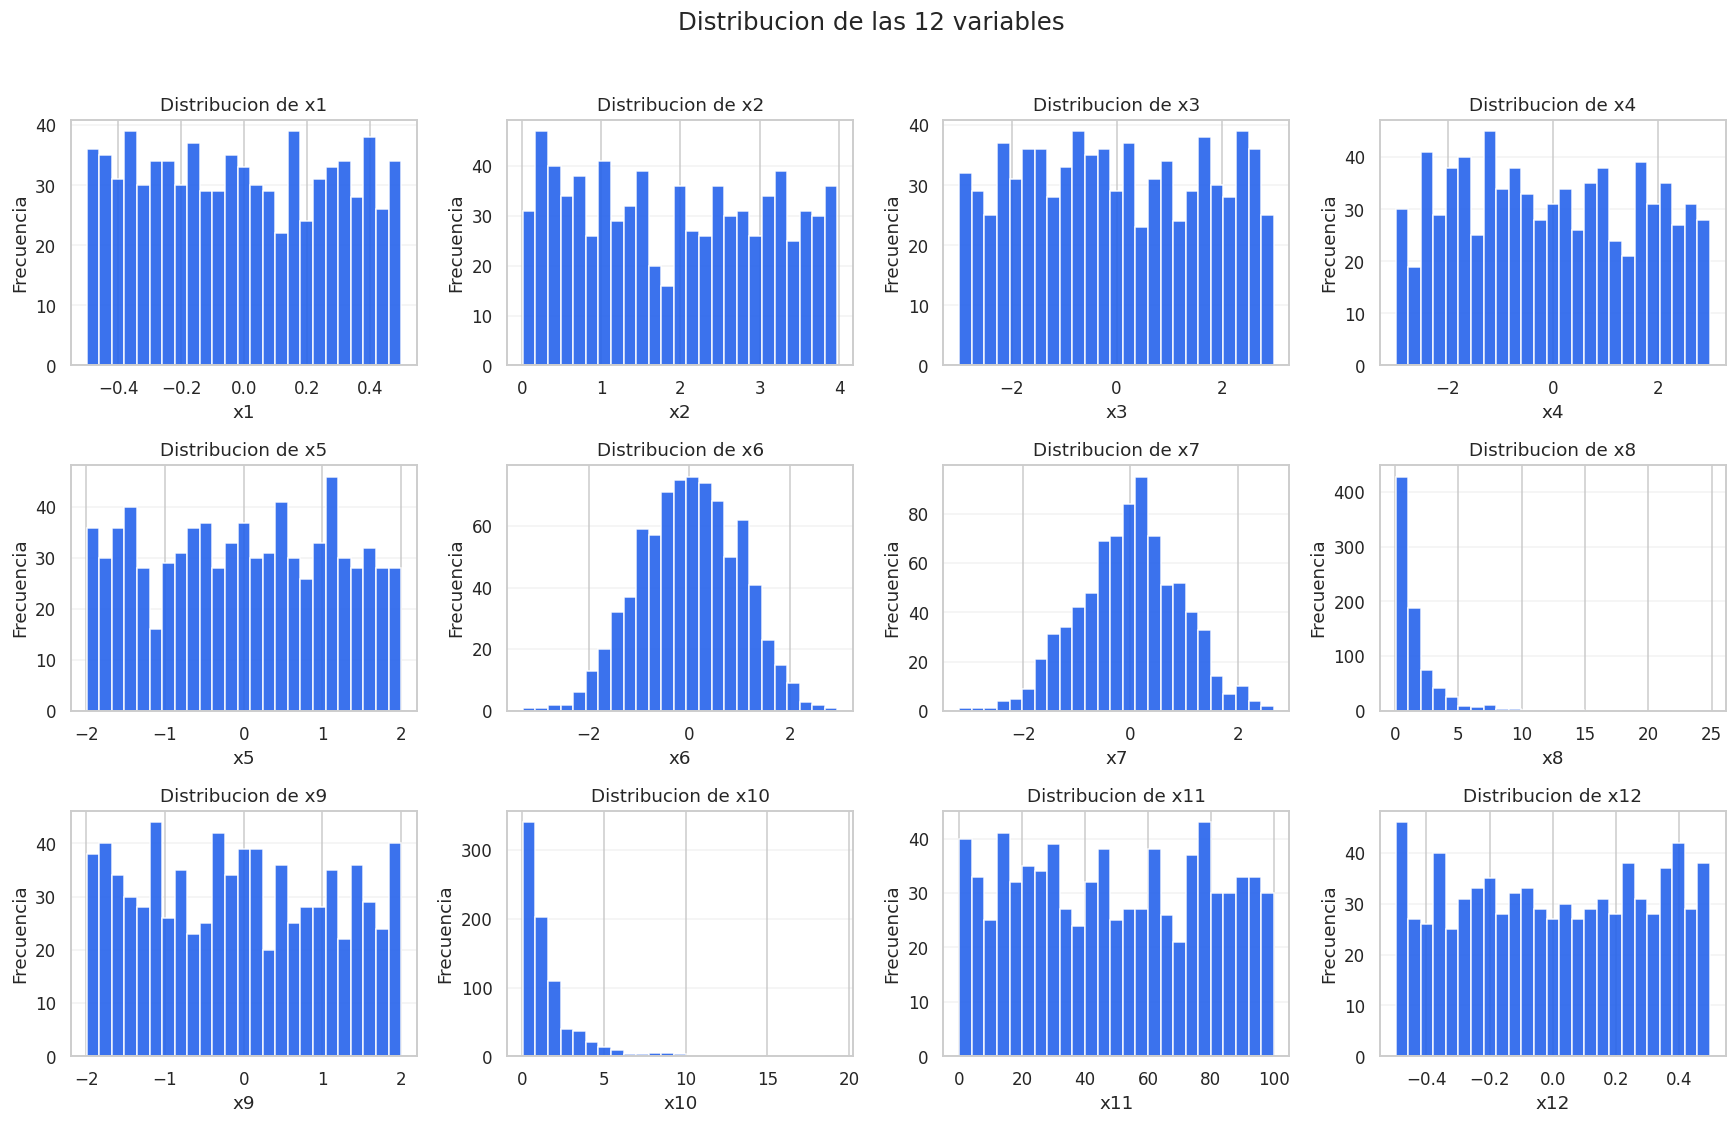

In [24]:
# Distribucion de cada una de las 12 variables.
fig, axes = plt.subplots(3, 4, figsize=(16, 10))

for ax, variable in zip(axes.flat, VARIABLES):
    ax.hist(train[variable], bins=25, color="#2563EB", edgecolor="white", alpha=0.9)
    ax.set_title(f"Distribucion de {variable}")
    ax.set_xlabel(variable)
    ax.set_ylabel("Frecuencia")
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("Distribucion de las 12 variables", fontsize=16, y=1.02)
fig.tight_layout()
plt.show()

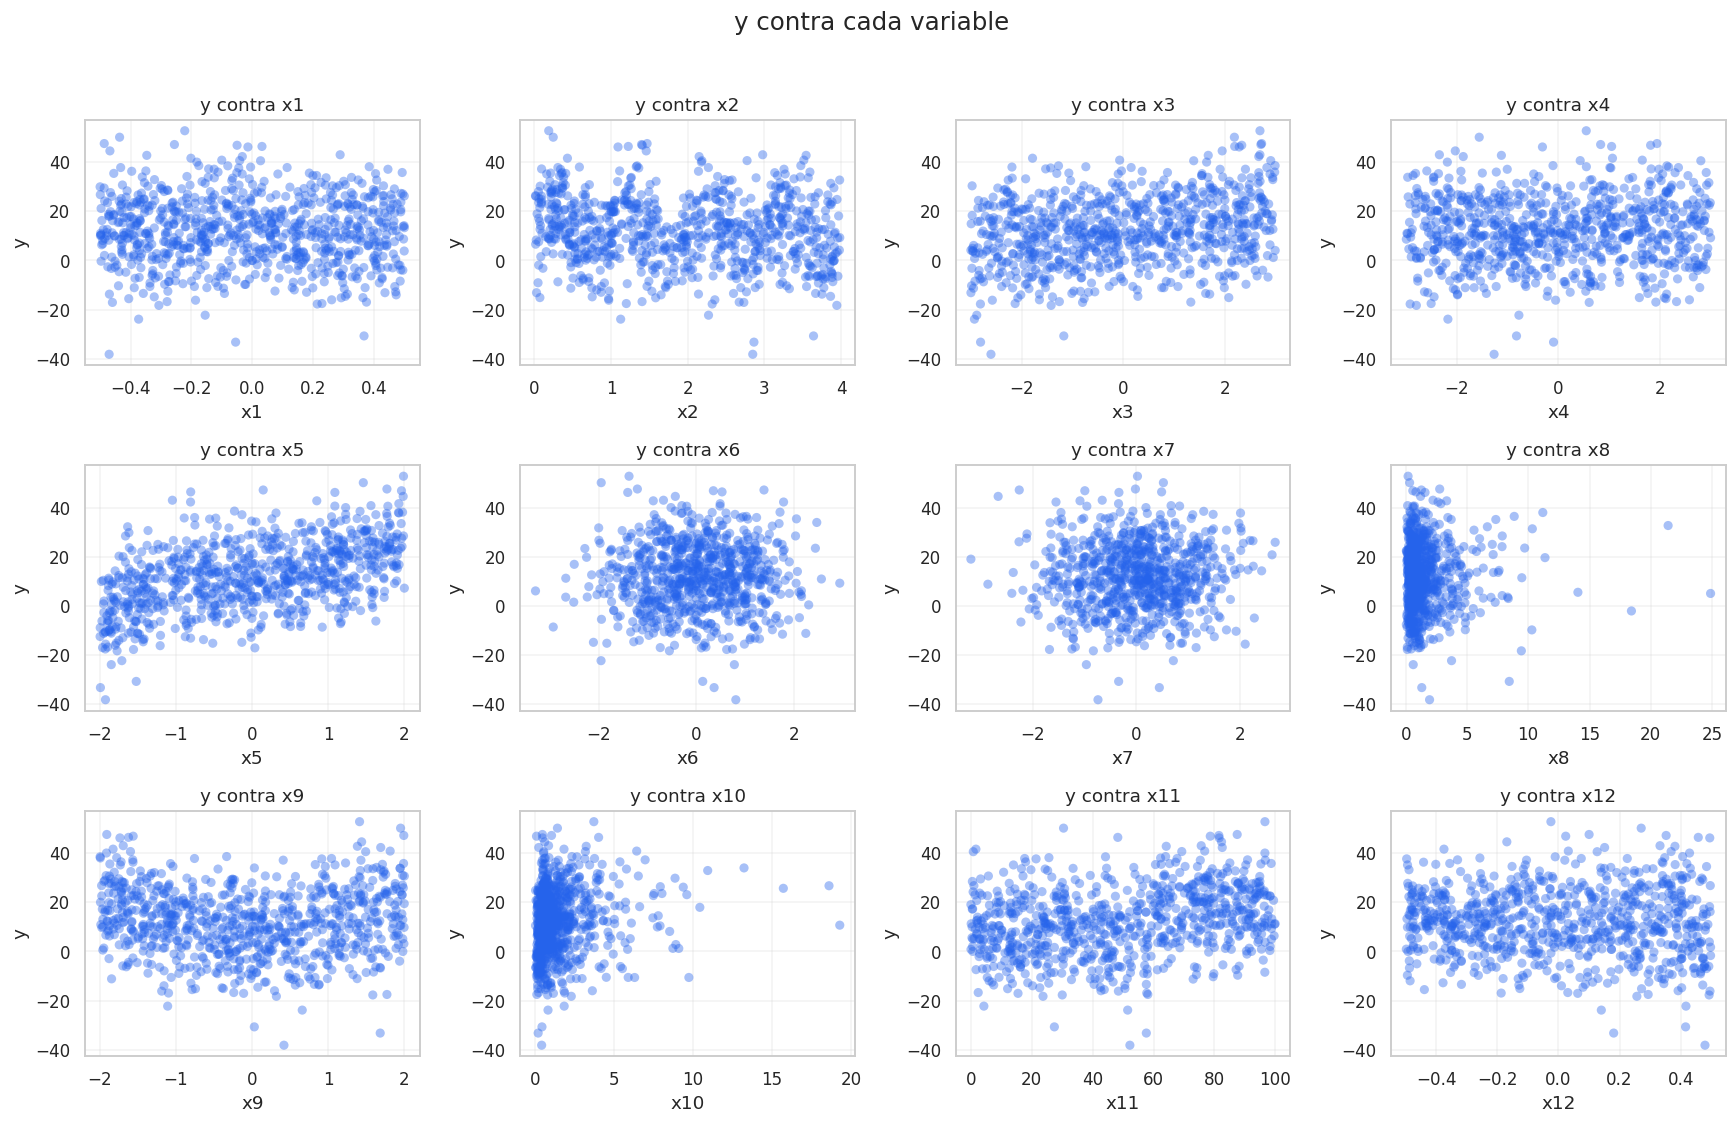

In [25]:

# y contra cada variable: una rejilla de 12 paneles.
fig, axes = plt.subplots(3, 4, figsize=(16, 10))

for ax, variable in zip(axes.flat, VARIABLES):
    ax.scatter(train[variable], train["y"], color="#2563EB", alpha=0.4, edgecolors="none")
    ax.set_title(f"y contra {variable}")
    ax.set_xlabel(variable)
    ax.set_ylabel("y")
    ax.grid(alpha=0.25)

fig.suptitle("y contra cada variable", fontsize=16, y=1.02)
fig.tight_layout()
plt.show()

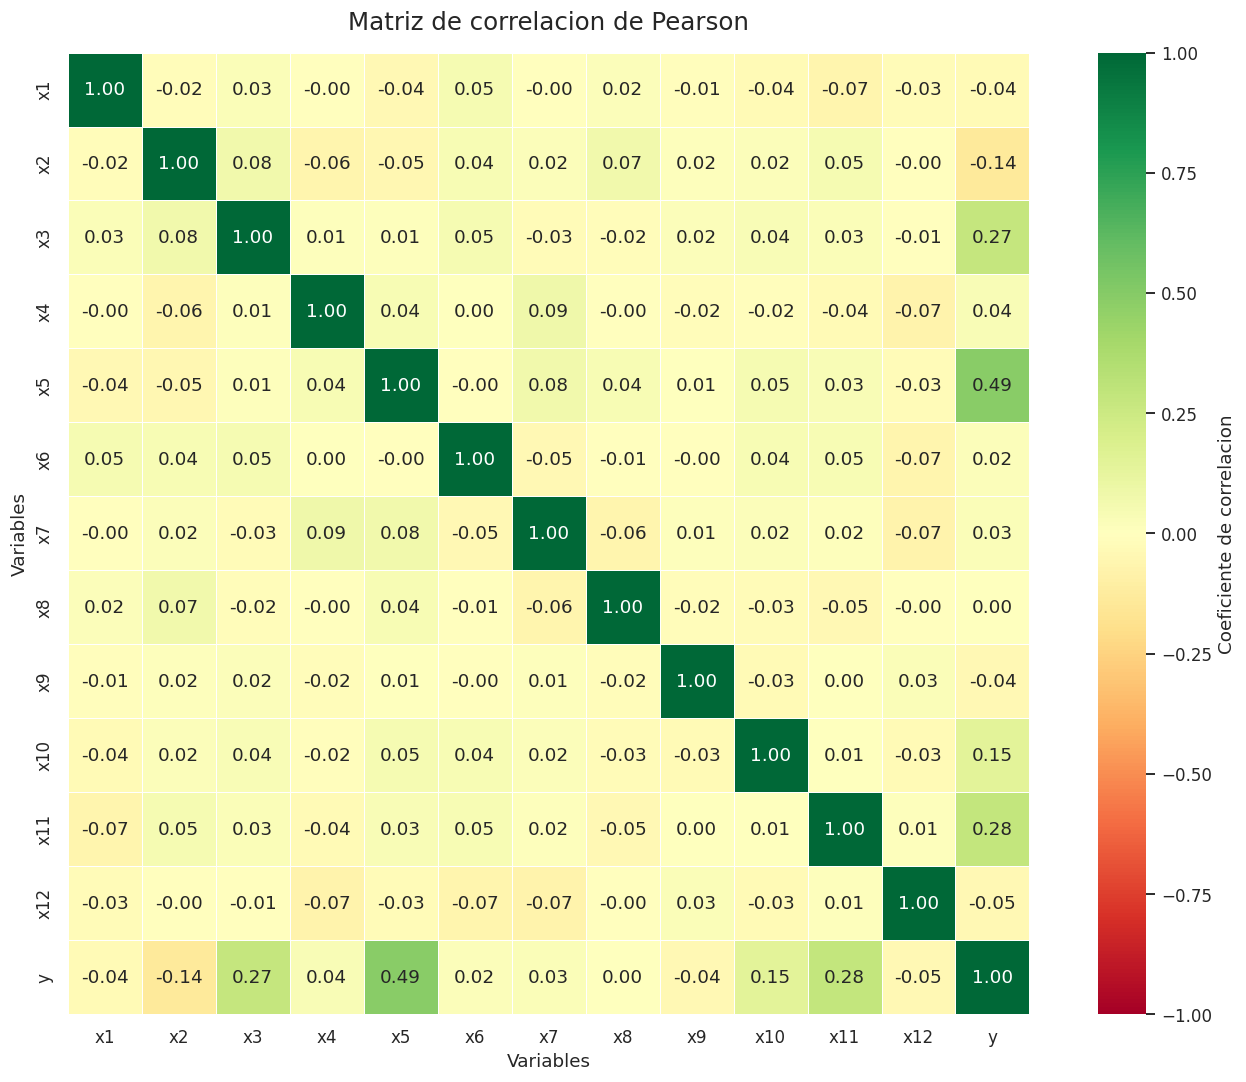

In [26]:
# Seleccionamos las 12 variables y agregamos la respuesta y.
# .corr() calcula por defecto las correlaciones de Pearson.
correlaciones = train[VARIABLES + ["y"]].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(
    correlaciones,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar_kws={"label": "Coeficiente de correlacion"},
)
plt.title("Matriz de correlacion de Pearson", fontsize=16, pad=15)
plt.xlabel("Variables")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

# Pearson mide asociacion lineal; una relacion en U puede tener correlacion cercana a cero.

### 1.1 Registren sus sospechas ahora

Estas son mis primeras observaciones. Falta revisar los residuos para ver si se sostienen.

| Variable | ¿Qué sospecho? | ¿En qué gráfica lo vi? | ¿Qué tan seguro estoy? |
| --- | --- | --- | --- |
| x1 | No veo una relación clara con y. | Dispersión y correlación de -0.04. | Poco. |
| x2 | Parece que y sube y baja; podría haber una relación que no sea recta. | Dispersión de y contra x2. | Poco. |
| x3 | Cuando aumenta x3, y parece aumentar también. | Dispersión y correlación de 0.27. | Más o menos. |
| x4 | No veo un patrón claro. | Dispersión y correlación de 0.04. | Poco. |
| x5 | Veo una relación positiva con y, aunque no sé si es completamente lineal. | Dispersión y correlación de 0.49. | Bastante sobre la tendencia. |
| x6 | Los datos se concentran cerca de cero, pero no veo una relación clara con y. | Histograma y dispersión. | Poco sobre su relación con y. |
| x7 | No distingo una tendencia con y. | Dispersión y correlación de 0.03. | Poco. |
| x8 | Hay muchos valores pequeños y pocos muy grandes. No veo cómo se relaciona con y. | Histograma y dispersión. | Poco sobre su relación con y. |
| x9 | Parece tener una forma de U; probaría un término al cuadrado. | Dispersión de y contra x9. | Más o menos. |
| x10 | Tiene una cola larga a la derecha y una relación positiva débil con y. | Histograma y correlación de 0.15. | Poco. |
| x11 | Parece que y aumenta cuando aumenta x11, aunque hay bastante dispersión. | Dispersión y correlación de 0.28. | Más o menos. |
| x12 | No veo una relación clara con y. | Dispersión y correlación de -0.05. | Poco. |

Que no vea una relación en estas gráficas no significa que la variable no sirva.


### 1.1 Registren sus sospechas ahora

Llenen esta tabla **antes** de seguir. Va a ser incómoda de llenar y eso es intencional:
la parte que enseña es volver a leerla al final y ver en qué se equivocaron.

| Variable | ¿Qué sospecho? | ¿En qué gráfica lo vi? | ¿Qué tan seguro estoy? |
|---|---|---|---|
| `x1` | | | |
| `x2` | | | |
| `x3` | | | |
| `x4` | | | |
| `x5` | | | |
| `x6` | | | |
| `x7` | | | |
| `x8` | | | |
| `x9` | | | |
| `x10` | | | |
| `x11` | | | |
| `x12` | | | |


---
## Parte 2. La escalera de residuales

Este es el método central de la tarea, y el que quiero que se lleven de por vida.

Un **residual** es lo que su modelo no logró explicar: `residual = y - ŷ`. Si su modelo
capturó todo lo que había, los residuales deben ser **ruido**: sin forma, sin patrón, sin
estructura. Si al graficar los residuales contra una variable se ve una *forma*, esa
forma es un pedazo de la función que les falta — y la forma les dice qué término agregar.

El ciclo es siempre el mismo:

1. Ajustan el modelo que tienen.
2. Grafican los residuales contra **cada** variable.
3. Si alguna gráfica tiene forma, agregan un término que capture esa forma.
4. Vuelven al paso 1.

Paran cuando ya ninguna gráfica tiene forma, o cuando el MSE deja de bajar.

### ¿Y qué término agrego?

Eso es exactamente lo que tienen que descubrir, y es el trabajo de la tarea.

Lo que sí les conviene es pedirle a su IA el **catálogo**: "¿qué transformaciones existen
para linealizar una relación no lineal?", "¿cómo se modela un efecto que cambia de golpe
a partir de cierto valor?". Eso es conocimiento general y la IA lo tiene completo.

Cuál de esas transformaciones aplica, a cuál de sus doce variables y con qué parámetro,
no se lo puede decir nadie: solo su gráfica. Ahí es donde se aprende.

In [27]:
def ajusta(columnas_extra=None):
    """Ajusta una lineal con las 12 crudas más las columnas derivadas que le pasen.

    `columnas_extra` es un dict {nombre: función que recibe un DataFrame y devuelve
    una Serie}. Así el mismo término se construye igual en train, validación y test,
    que es donde se equivoca todo el mundo.

    Devuelve (modelo, mse_validacion, residuales_de_validacion, constructor).
    """
    columnas_extra = columnas_extra or {}

    def construye(df):
        salida = df[VARIABLES].copy()
        for nombre, f in columnas_extra.items():
            salida[nombre] = f(df)
        return salida

    modelo = LinearRegression().fit(construye(X_train), y_train)
    pred_val = modelo.predict(construye(X_val))
    mse = mean_squared_error(y_val, pred_val)
    return modelo, mse, y_val - pred_val, construye


modelo, mse, residuales, _ = ajusta()
print(f"Modelo con las 12 crudas -> MSE de validación {mse:.2f}")

Modelo con las 12 crudas -> MSE de validación 121.24


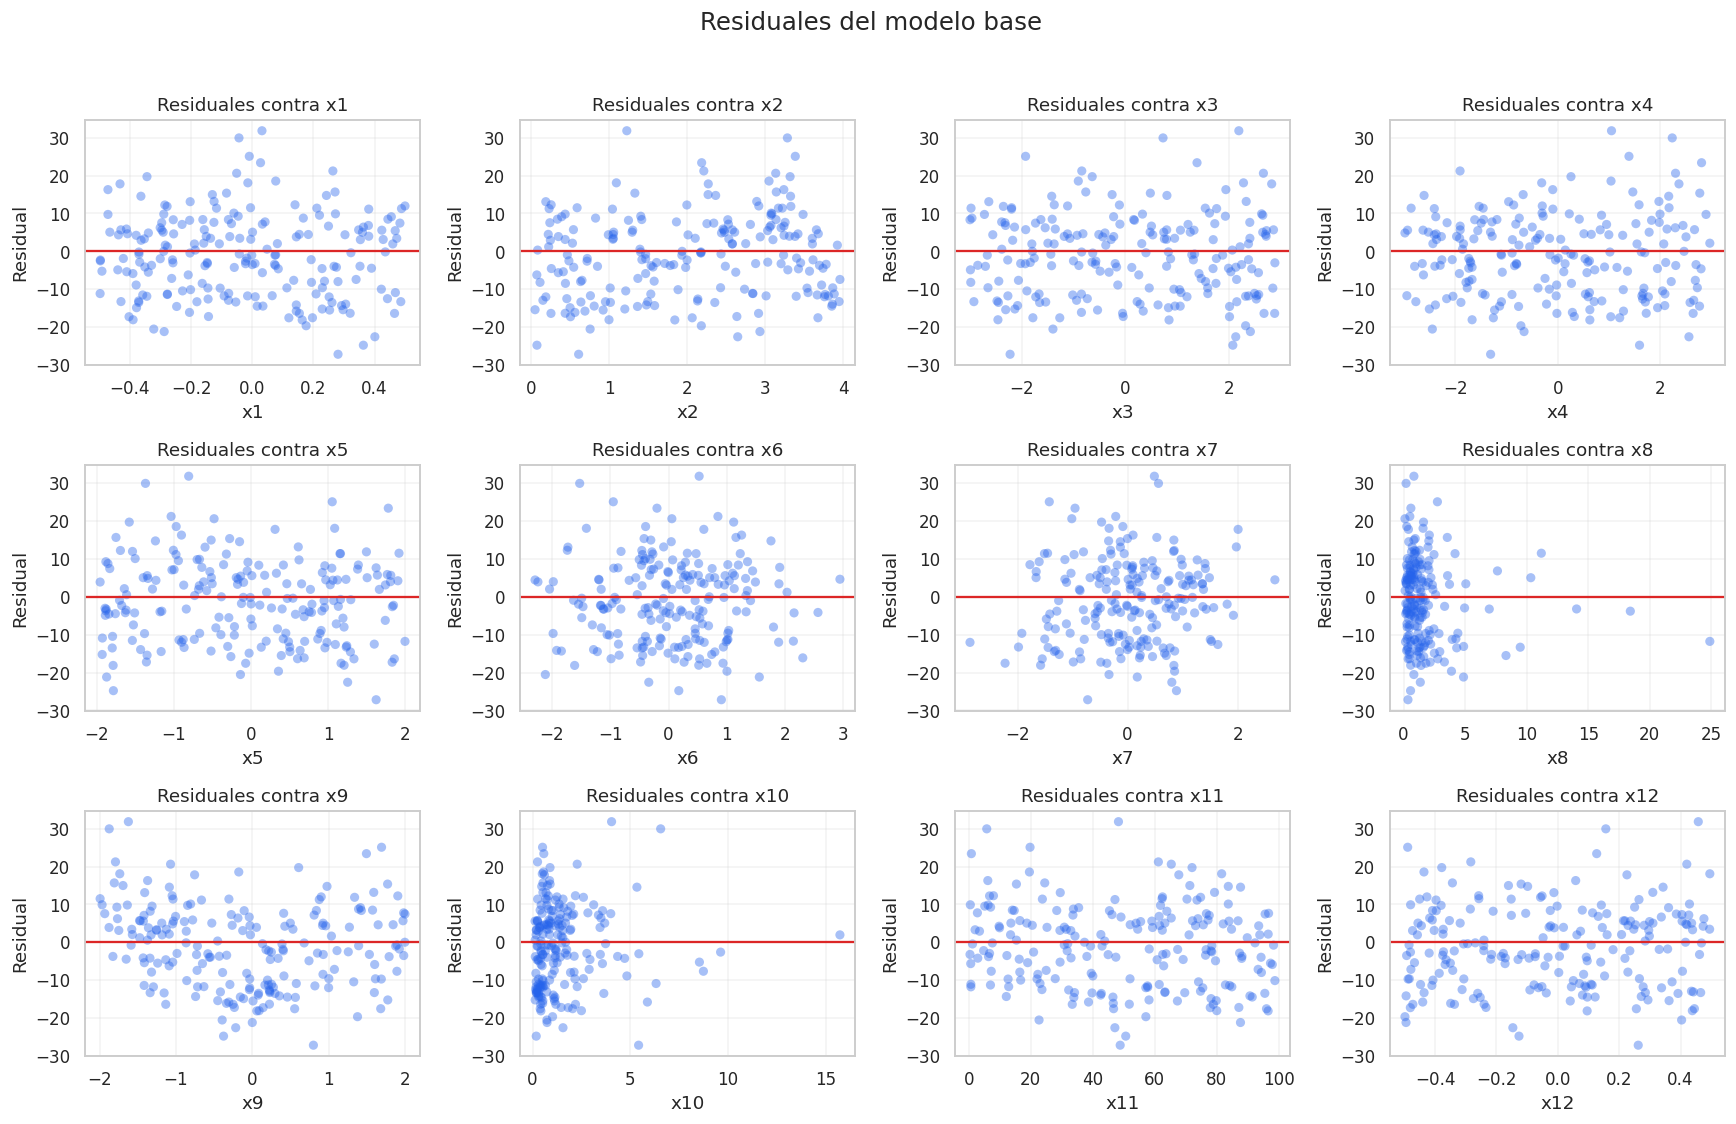

In [28]:
# Residuales del modelo base contra cada una de las 12 variables.
fig, axes = plt.subplots(3, 4, figsize=(16, 10))

for ax, variable in zip(axes.flat, VARIABLES):
    ax.scatter(X_val[variable], residuales, color="#2563EB", alpha=0.4, edgecolors="none")
    ax.axhline(0, color="#DC2626", linewidth=1.5)
    ax.set_title(f"Residuales contra {variable}")
    ax.set_xlabel(variable)
    ax.set_ylabel("Residual")
    ax.grid(alpha=0.25)

fig.suptitle("Residuales del modelo base", fontsize=16, y=1.02)
fig.tight_layout()
plt.show()

MSE del modelo base: 121.24
MSE al agregar x5^2: 121.03
Cambio: -0.21
Comentario: la mejora es pequeña, pero la hipótesis se conserva para seguir explorando.


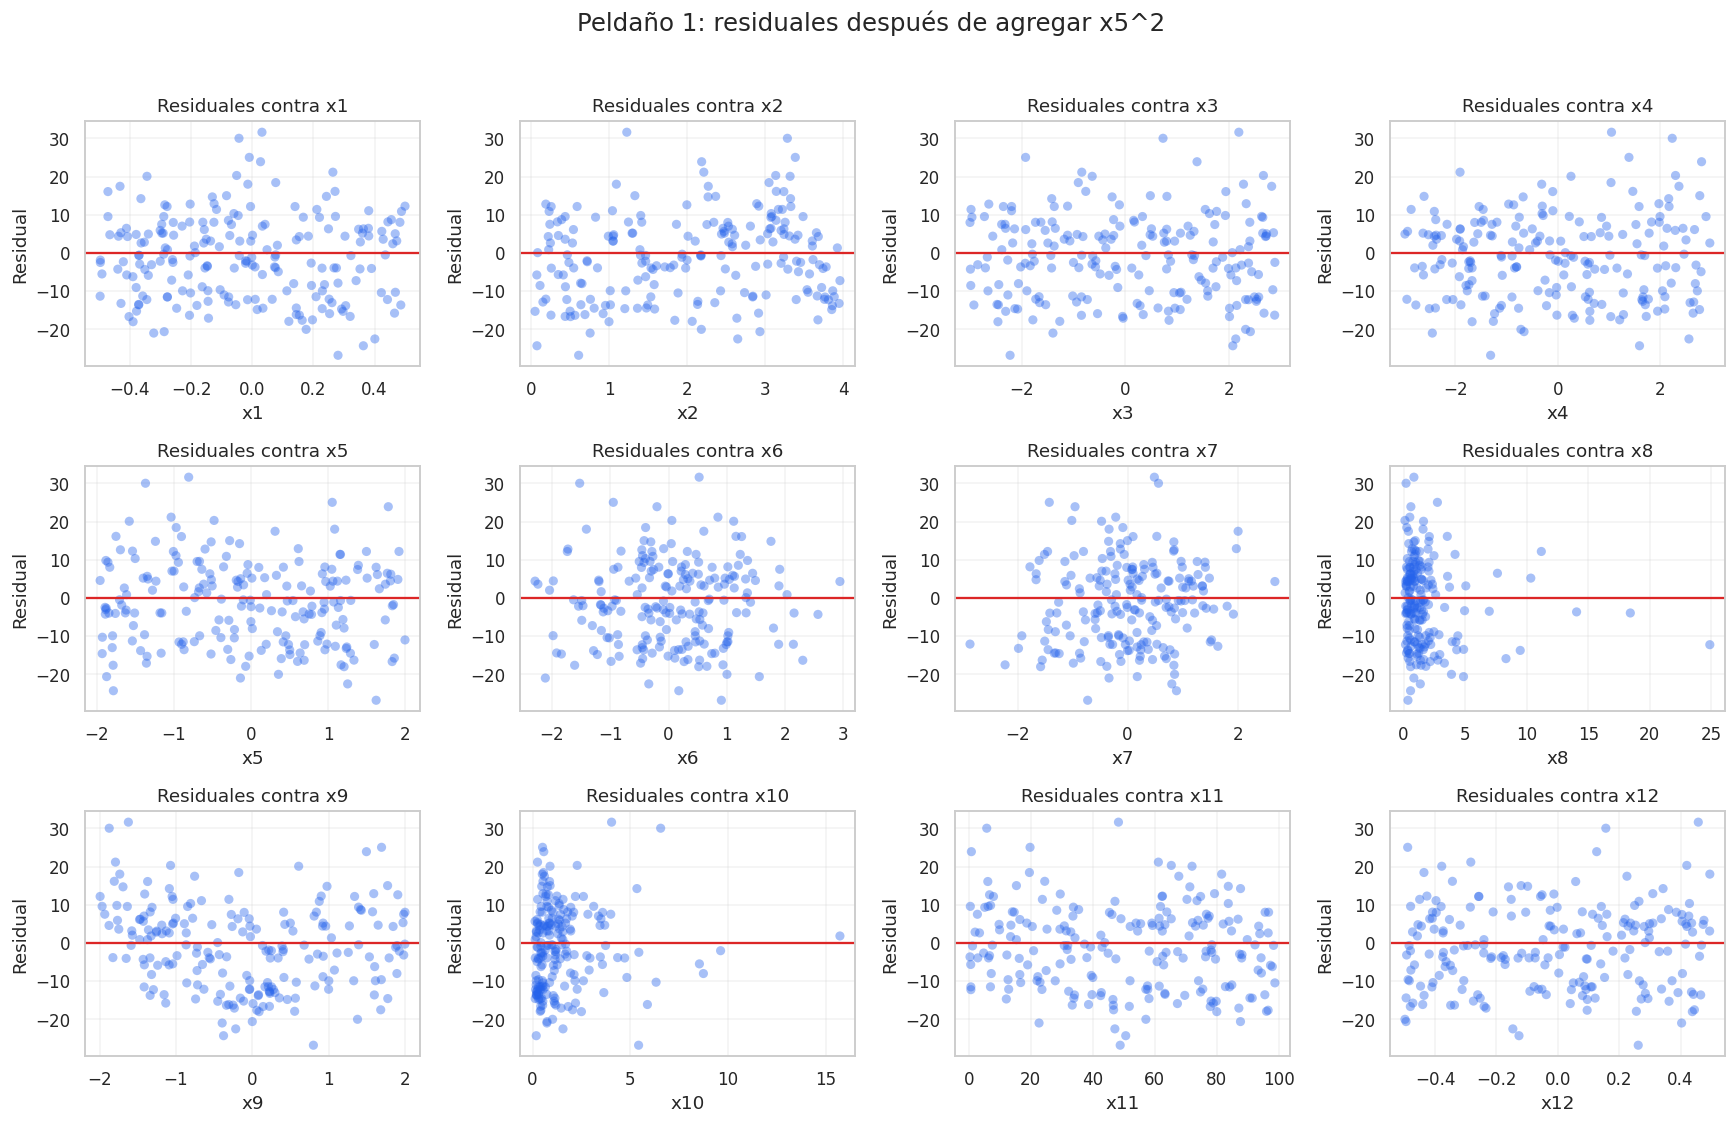

In [29]:
# Peldaño 1: en la gráfica base, x5 sugiere una relación con curvatura.
MEJORES_TERMINOS = {
    "x5_cuadrado": lambda d: d["x5"] ** 2,
}

modelo_x5_cuadrado, mse_x5_cuadrado, residuales_x5_cuadrado, _ = ajusta(MEJORES_TERMINOS)
print(f"MSE del modelo base: {mse_baseline:.2f}")
print(f"MSE al agregar x5^2: {mse_x5_cuadrado:.2f}")
print(f"Cambio: {mse_x5_cuadrado - mse_baseline:.2f}")
print("Comentario: la mejora es pequeña, pero la hipótesis se conserva para seguir explorando.")

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, variable in zip(axes.flat, VARIABLES):
    ax.scatter(X_val[variable], residuales_x5_cuadrado, color="#2563EB", alpha=0.4, edgecolors="none")
    ax.axhline(0, color="#DC2626", linewidth=1.5)
    ax.set_title(f"Residuales contra {variable}")
    ax.set_xlabel(variable)
    ax.set_ylabel("Residual")
    ax.grid(alpha=0.25)
fig.suptitle("Peldaño 1: residuales después de agregar x5^2", fontsize=16, y=1.02)
fig.tight_layout()
plt.show()

Peldaño 2 | MSE: 101.27 | Cambio: -19.76
Comentario: x9^2 mejora mucho porque captura la curvatura en forma de U.


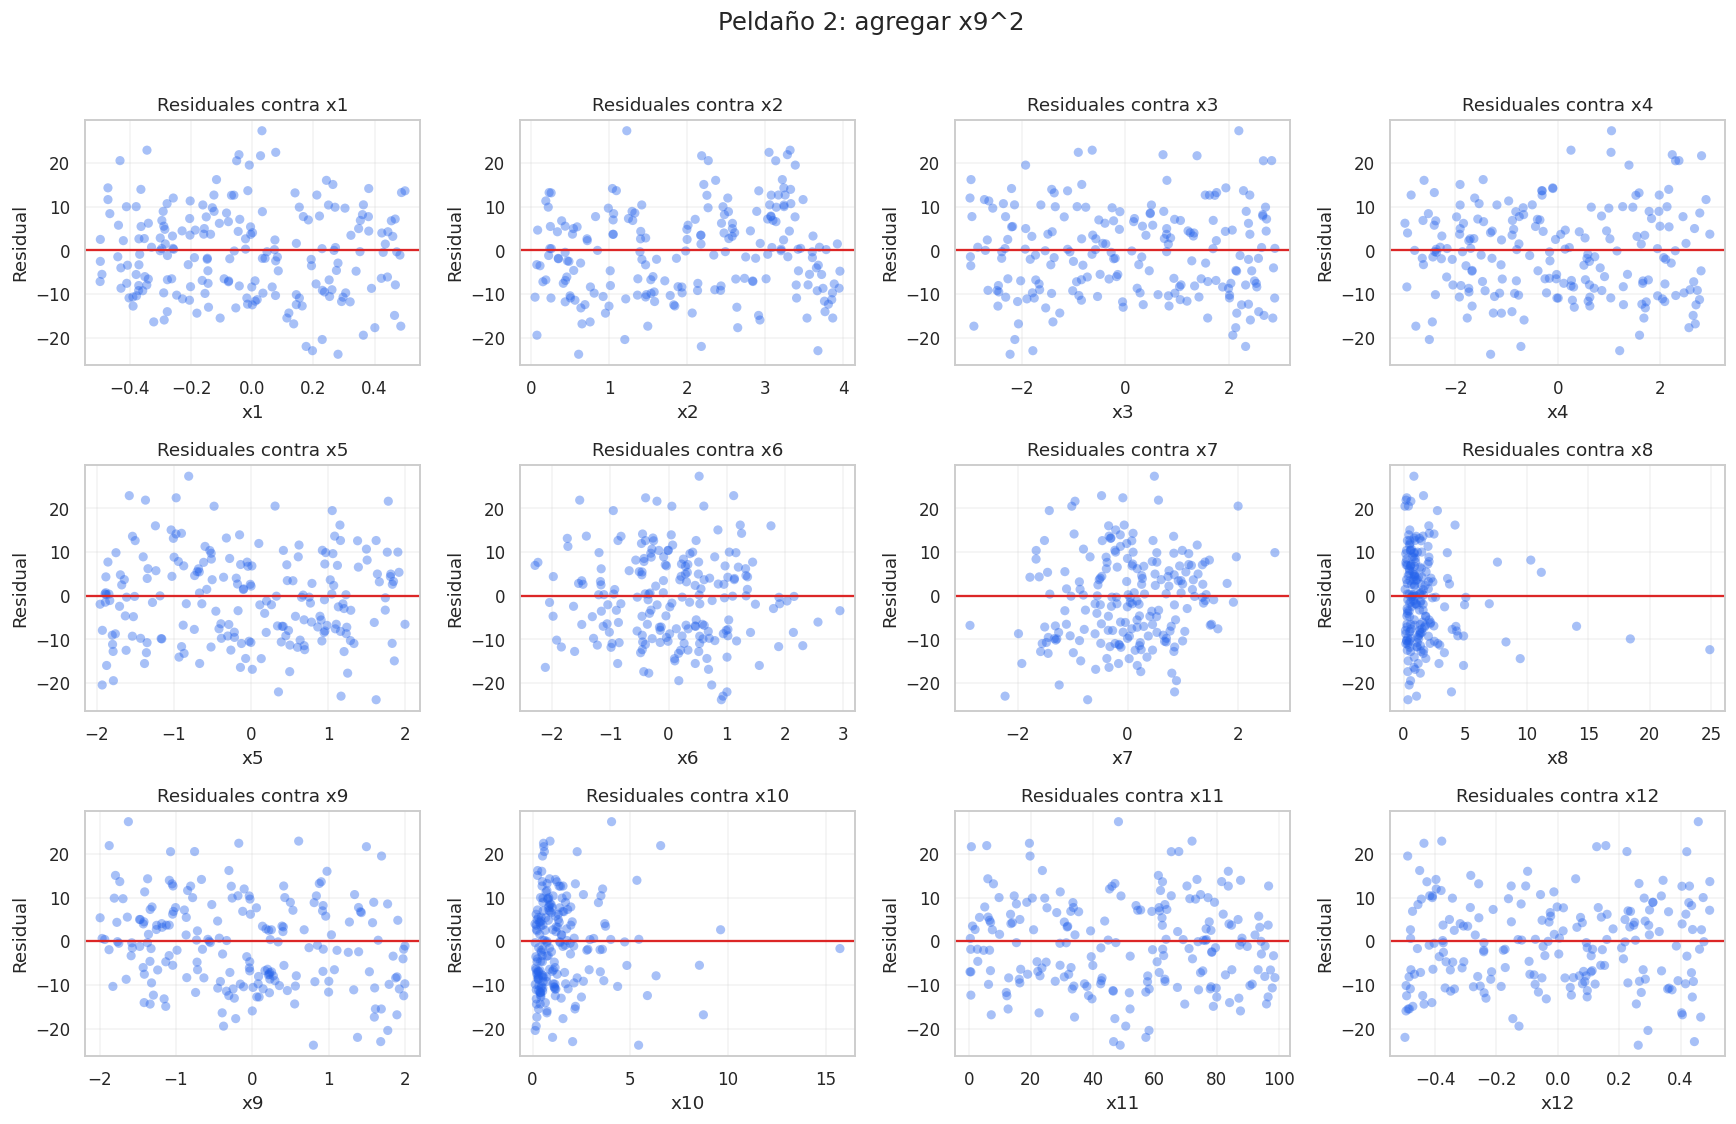

Peldaño 3 | MSE: 101.20 | Cambio: -0.07
Comentario: x4^2 casi no baja el MSE; no se conserva en el modelo.


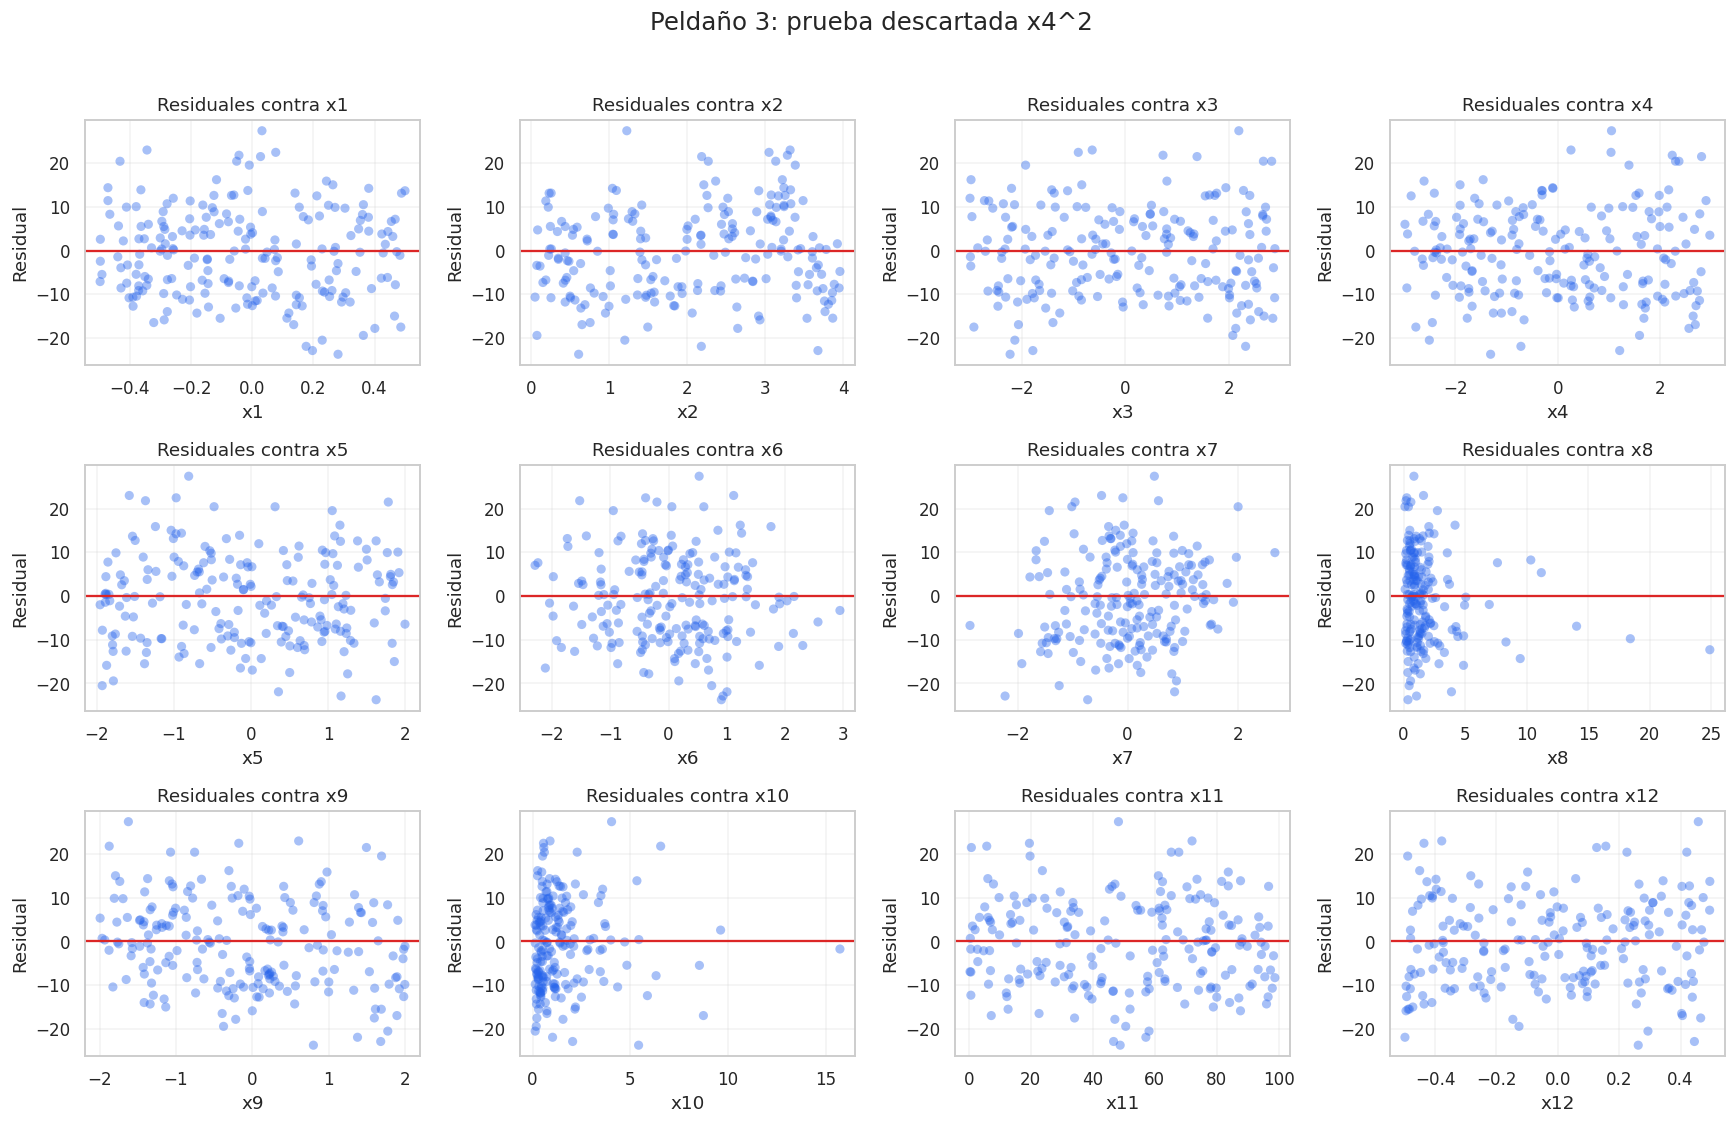

Peldaño 4 | MSE: 101.83 | Cambio: 0.56
Comentario: x9^3 empeora el MSE; la curvatura de x9 ya está bien representada con x9^2.


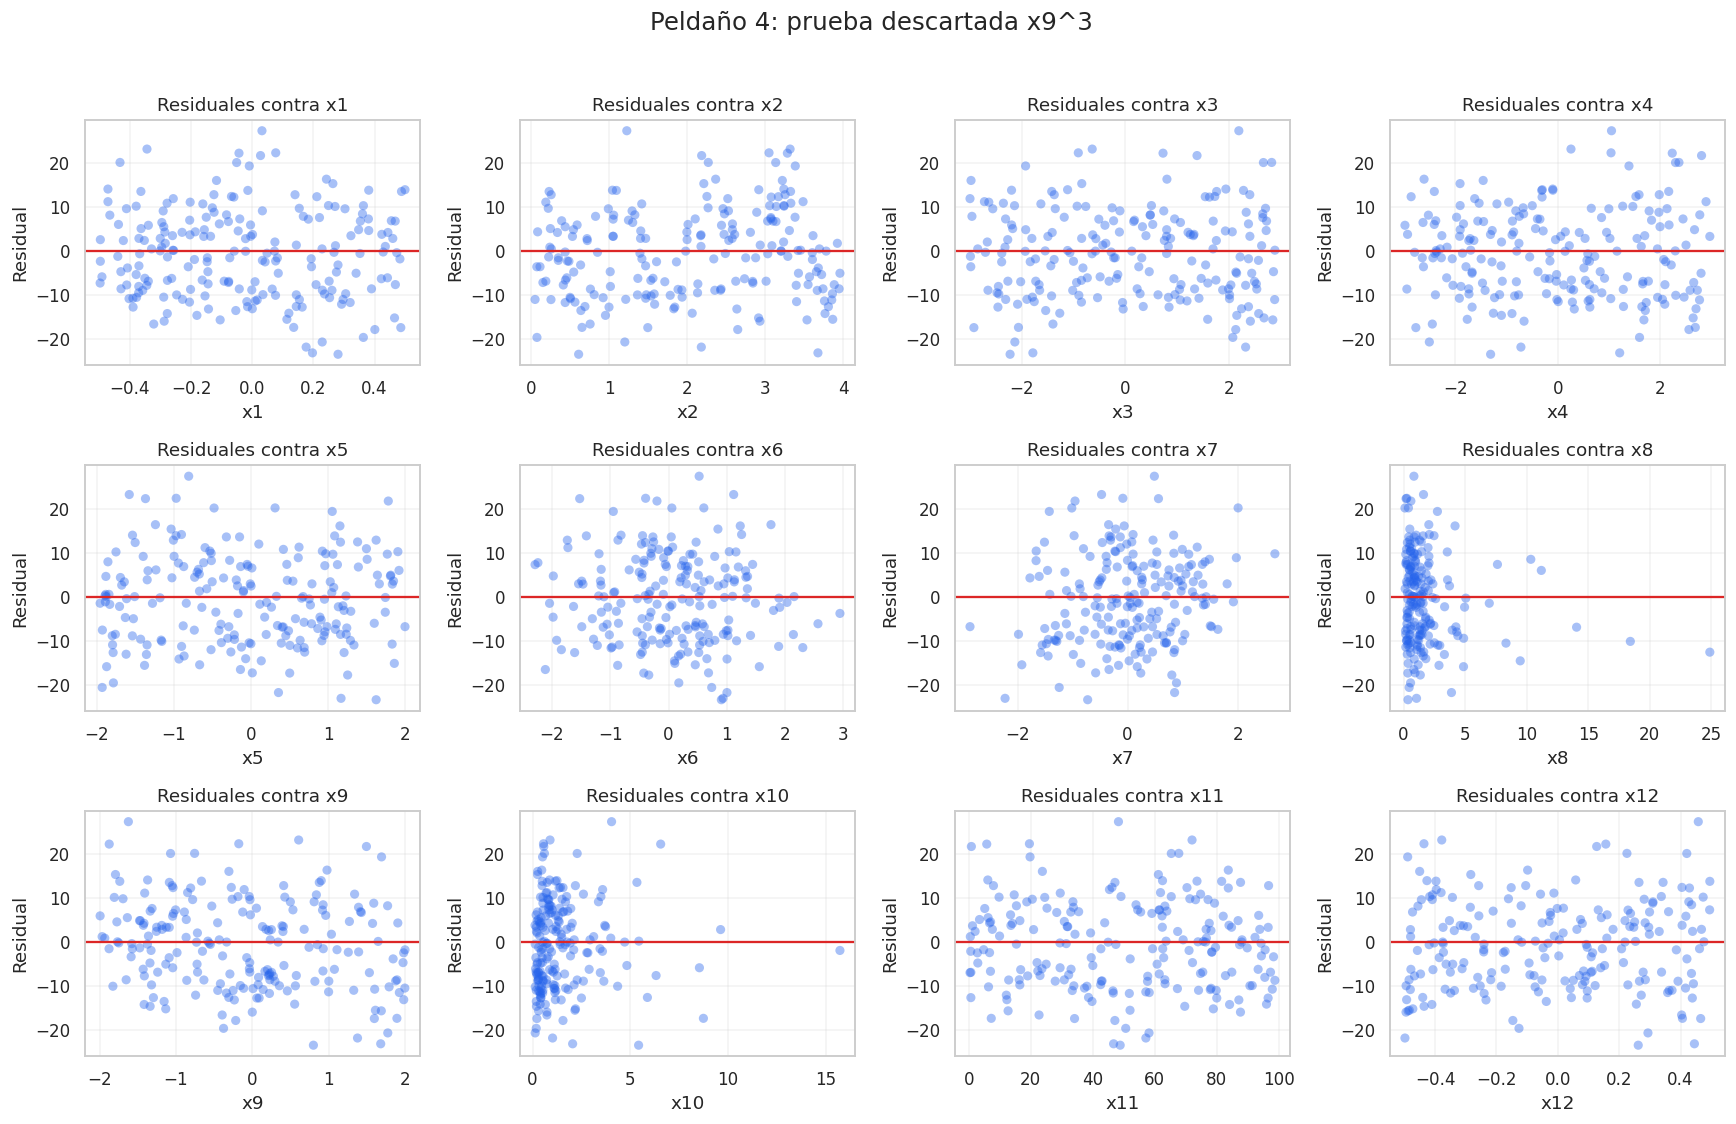

Peldaño 5 | MSE: 95.65 | Cambio: -5.62
Comentario: x5^3 captura una asimetría que x5^2 no podía representar.


In [ ]:
def grafica_residuales(residuales_modelo, titulo):
    """Muestra una rejilla de residuales contra las 12 variables."""
    fig, axes = plt.subplots(3, 4, figsize=(16, 10))
    for ax, variable in zip(axes.flat, VARIABLES):
        ax.scatter(
            X_val[variable],
            residuales_modelo,
            color="#2563EB",
            alpha=0.4,
            edgecolors="none",
        )
        ax.axhline(0, color="#DC2626", linewidth=1.5)
        ax.set_title(f"Residuales contra {variable}")
        ax.set_xlabel(variable)
        ax.set_ylabel("Residual")
        ax.grid(alpha=0.25)
    fig.suptitle(titulo, fontsize=16, y=1.02)
    fig.tight_layout()
    plt.show()

historial = [("Modelo base", mse_baseline)]

# Peldaño 2: x9 muestra una forma de U, por eso probamos x9^2.
terminos_x5_x9 = {
    "x5_cuadrado": lambda d: d["x5"] ** 2,
    "x9_cuadrado": lambda d: d["x9"] ** 2,
}
modelo_x5_x9, mse_x5_x9, residuales_x5_x9, _ = ajusta(terminos_x5_x9)
historial.append(("x5^2 + x9^2", mse_x5_x9))
print(f"Peldaño 2 | MSE: {mse_x5_x9:.2f} | Cambio: {mse_x5_x9 - mse_x5_cuadrado:.2f}")
print("Comentario: x9^2 mejora mucho porque captura la curvatura en forma de U.")
grafica_residuales(residuales_x5_x9, "Peldaño 2: agregar x9^2")

# Peldaño 3: probamos x4^2, pero la mejora es mínima y se descarta.
terminos_x4 = {**terminos_x5_x9, "x4_cuadrado": lambda d: d["x4"] ** 2}
modelo_x5_x9_x4, mse_x5_x9_x4, residuales_x5_x9_x4, _ = ajusta(terminos_x4)
historial.append(("Prueba x4^2 (descartada)", mse_x5_x9_x4))
print(f"Peldaño 3 | MSE: {mse_x5_x9_x4:.2f} | Cambio: {mse_x5_x9_x4 - mse_x5_x9:.2f}")
print("Comentario: x4^2 casi no baja el MSE; no se conserva en el modelo.")
grafica_residuales(residuales_x5_x9_x4, "Peldaño 3: prueba descartada x4^2")

# Peldaño 4: probamos x9^3, pero empeora el modelo y se descarta.
terminos_x9_cubico = {**terminos_x5_x9, "x9_cubico": lambda d: d["x9"] ** 3}
modelo_x5_x9_cubico, mse_x5_x9_cubico, residuales_x5_x9_cubico, _ = ajusta(terminos_x9_cubico)
historial.append(("Prueba x9^3 (descartada)", mse_x5_x9_cubico))
print(f"Peldaño 4 | MSE: {mse_x5_x9_cubico:.2f} | Cambio: {mse_x5_x9_cubico - mse_x5_x9:.2f}")
print("Comentario: x9^3 empeora el MSE; la curvatura de x9 ya está bien representada con x9^2.")
grafica_residuales(residuales_x5_x9_cubico, "Peldaño 4: prueba descartada x9^3")

# Peldaño 5: x5^3 mejora la forma restante asociada con x5.
MEJORES_TERMINOS = {
    "x5_cuadrado": lambda d: d["x5"] ** 2,
    "x9_cuadrado": lambda d: d["x9"] ** 2,
    "x5_cubico": lambda d: d["x5"] ** 3,
}
modelo_x5_cubico, mse_x5_cubico, residuales_x5_cubico, _ = ajusta(MEJORES_TERMINOS)
historial.append(("x5^2 + x9^2 + x5^3", mse_x5_cubico))
print(f"Peldaño 5 | MSE: {mse_x5_cubico:.2f} | Cambio: {mse_x5_cubico - mse_x5_x9:.2f}")
print("Comentario: x5^3 captura una asimetría que x5^2 no podía representar.")
grafica_residuales(residuales_x5_cubico, "Peldaño 5: agregar x5^3")

# Peldaño 6: exploramos x12^2 y x10^2 como alternativas adicionales.
for nombre, termino in [
    ("x12^2", lambda d: d["x12"] ** 2),
    ("x10^2", lambda d: d["x10"] ** 2),
]:
    terminos_prueba = {**MEJORES_TERMINOS, nombre.replace("^", "_"): termino}
    _, mse_prueba, residuales_prueba, _ = ajusta(terminos_prueba)
    historial.append((f"Prueba {nombre}", mse_prueba))
    print(f"Peldaño 6 | {nombre} | MSE: {mse_prueba:.2f} | Cambio: {mse_prueba - mse_x5_cubico:.2f}")
    print("Comentario: se conserva solo si reduce claramente el MSE; estas pruebas se documentan aunque fallen.")
    grafica_residuales(residuales_prueba, f"Peldaño 6: prueba {nombre}")

modelo_parte2, mse_parte2, residuales_parte2, _ = ajusta(MEJORES_TERMINOS)
print(f"MSE final de la Parte 2: {mse_parte2:.2f}")

historial_df = pd.DataFrame(historial, columns=["Hipotesis", "MSE"])
historial_df

MSE final de la Parte 2: 95.20
Comentario: x10^2 se conserva porque fue la mejor prueba adicional medida.


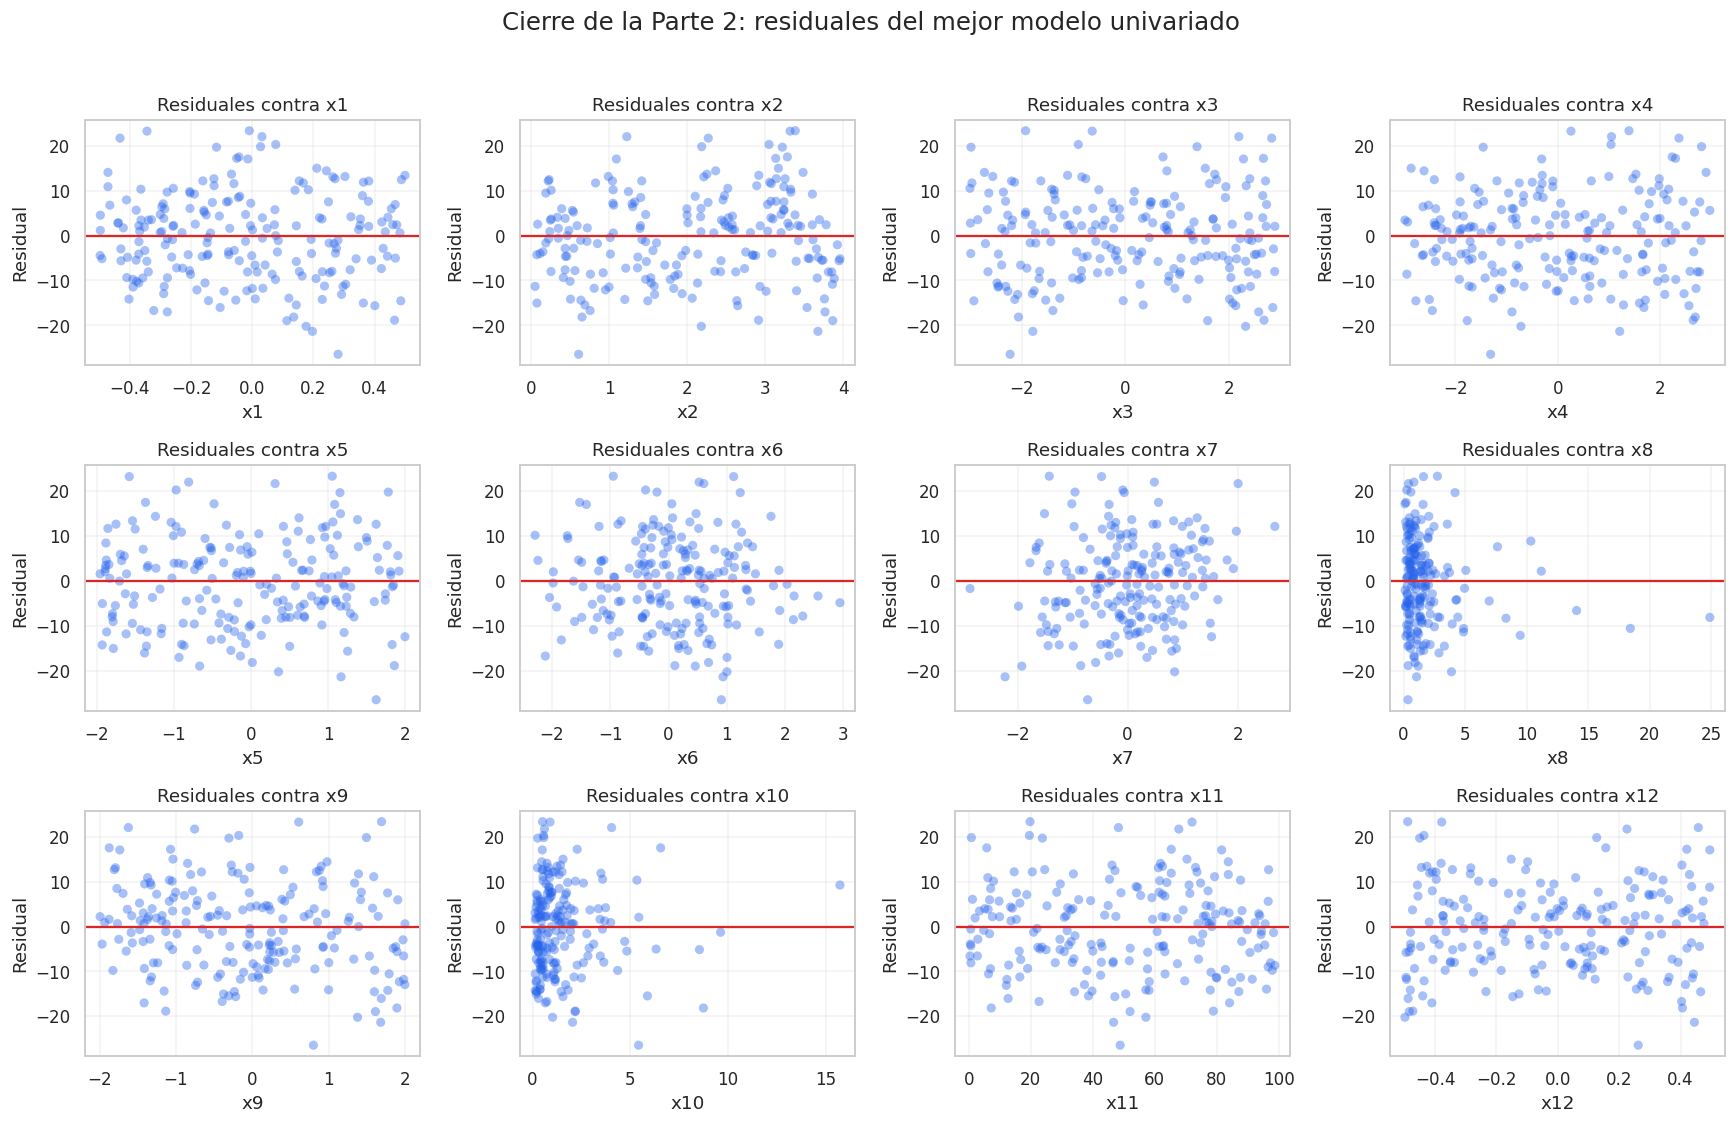

In [ ]:
# Cierre de la Parte 2: conservamos la mejor prueba univariada observada.
# x10^2 fue mejor que el modelo anterior, aunque la mejora es moderada.
MEJORES_TERMINOS = {
    "x5_cuadrado": lambda d: d["x5"] ** 2,
    "x9_cuadrado": lambda d: d["x9"] ** 2,
    "x5_cubico": lambda d: d["x5"] ** 3,
    "x10_cuadrado": lambda d: d["x10"] ** 2,
}

modelo_parte2, mse_parte2, residuales_parte2, _ = ajusta(MEJORES_TERMINOS)
print(f"MSE final de la Parte 2: {mse_parte2:.2f}")
print("Comentario: x10^2 se conserva porque fue la mejor prueba adicional medida.")

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, variable in zip(axes.flat, VARIABLES):
    ax.scatter(X_val[variable], residuales_parte2, color="#2563EB", alpha=0.4, edgecolors="none")
    ax.axhline(0, color="#DC2626", linewidth=1.5)
    ax.set_title(f"Residuales contra {variable}")
    ax.set_xlabel(variable)
    ax.set_ylabel("Residual")
    ax.grid(alpha=0.25)
fig.suptitle("Cierre de la Parte 2: residuales del mejor modelo univariado", fontsize=16, y=1.02)
fig.tight_layout()
plt.show()

---
## Parte 3. Lo que las gráficas de una variable no pueden ver

Cuando terminen la Parte 2 van a tener un modelo decente y, probablemente, ninguna
gráfica de residuales con forma evidente. Eso **no** significa que ya acabaron.

Hay efectos que son invisibles para cualquier gráfica de una sola variable: pueden tener
correlación cero con `y`, scatter plano y residual sin estructura, y aun así ser de los
efectos más grandes del modelo. Ninguna herramienta de la Parte 2 los encuentra.

Su trabajo aquí es averiguar **qué clase de efectos son, cómo se detectan, y si sus datos
tienen alguno**. Su IA les puede explicar la teoría si le hacen la pregunta correcta; sus
datos son los únicos que pueden contestar si aplica.

Una pista de método y ninguna de contenido: si mirar una variable a la vez no basta,
prueben mirando dos a la vez.

In [ ]:
# Exploramos posibles interacciones entre pares de variables.
from itertools import combinations

interacciones = []
for variable_1, variable_2 in combinations(VARIABLES, 2):
    producto = X_val[variable_1] * X_val[variable_2]
    correlacion = np.corrcoef(producto, residuales_parte2)[0, 1]
    interacciones.append(
        {
            "variable_1": variable_1,
            "variable_2": variable_2,
            "correlacion_abs": abs(correlacion),
            "correlacion": correlacion,
        }
    )

interacciones = pd.DataFrame(interacciones).sort_values("correlacion_abs", ascending=False)
print("Pares cuyo producto tiene mayor asociación con los residuales:")
interacciones.head(10)

Pares cuyo producto tiene mayor asociación con los residuales:


,variable_1,variable_2,correlacion_abs,correlacion
29,x3,x12,0.646435,0.646435
60,x9,x10,0.229108,-0.229108
17,x2,x9,0.182929,-0.182929
54,x7,x11,0.177329,0.177329
48,x6,x10,0.172327,-0.172327
61,x9,x11,0.157220,-0.157220
15,x2,x7,0.147218,0.147218
53,x7,x10,0.140725,0.140725
62,x9,x12,0.138246,-0.138246
47,x6,x9,0.129876,-0.129876


Peldaño | x3*x12 | MSE: 56.63 | Cambio: -38.57
Comentario: la interacción reduce el MSE y se conserva como hipótesis activa.


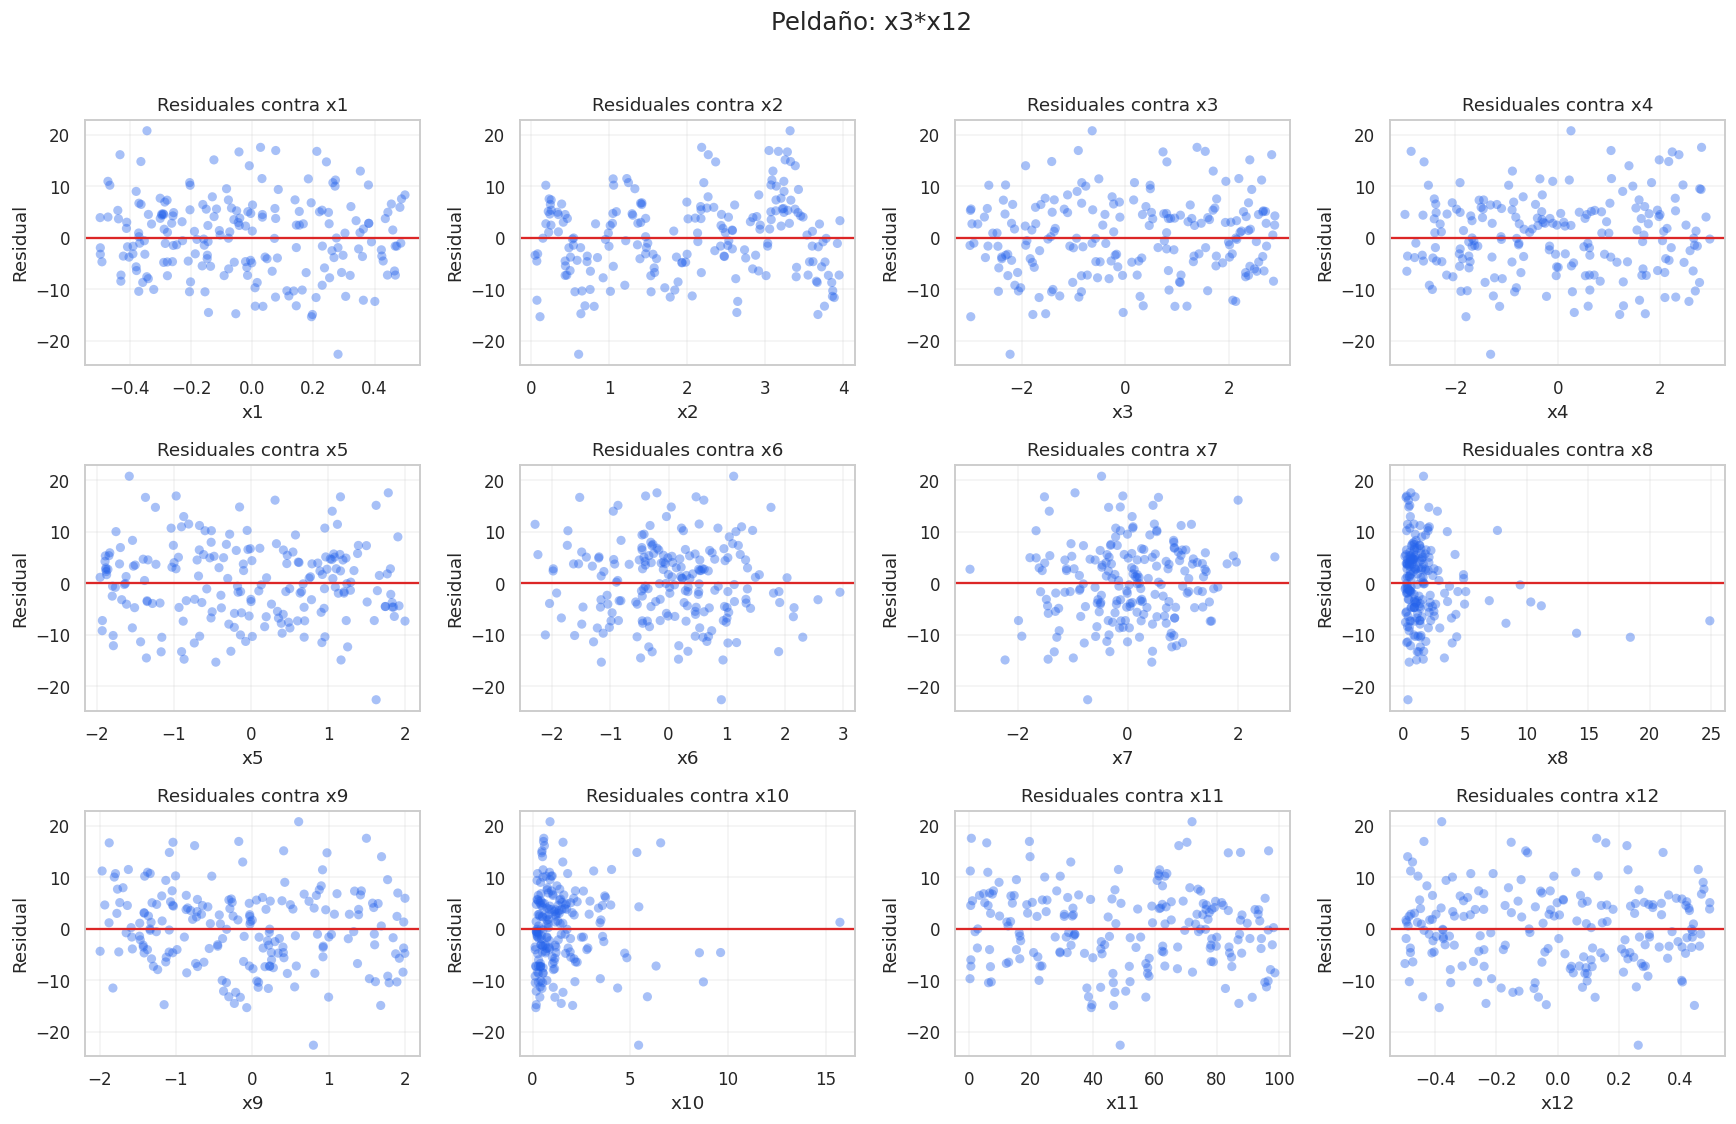

Peldaño | x5*x9 | MSE: 94.21 | Cambio: -0.99
Comentario: la interacción reduce el MSE y se conserva como hipótesis activa.


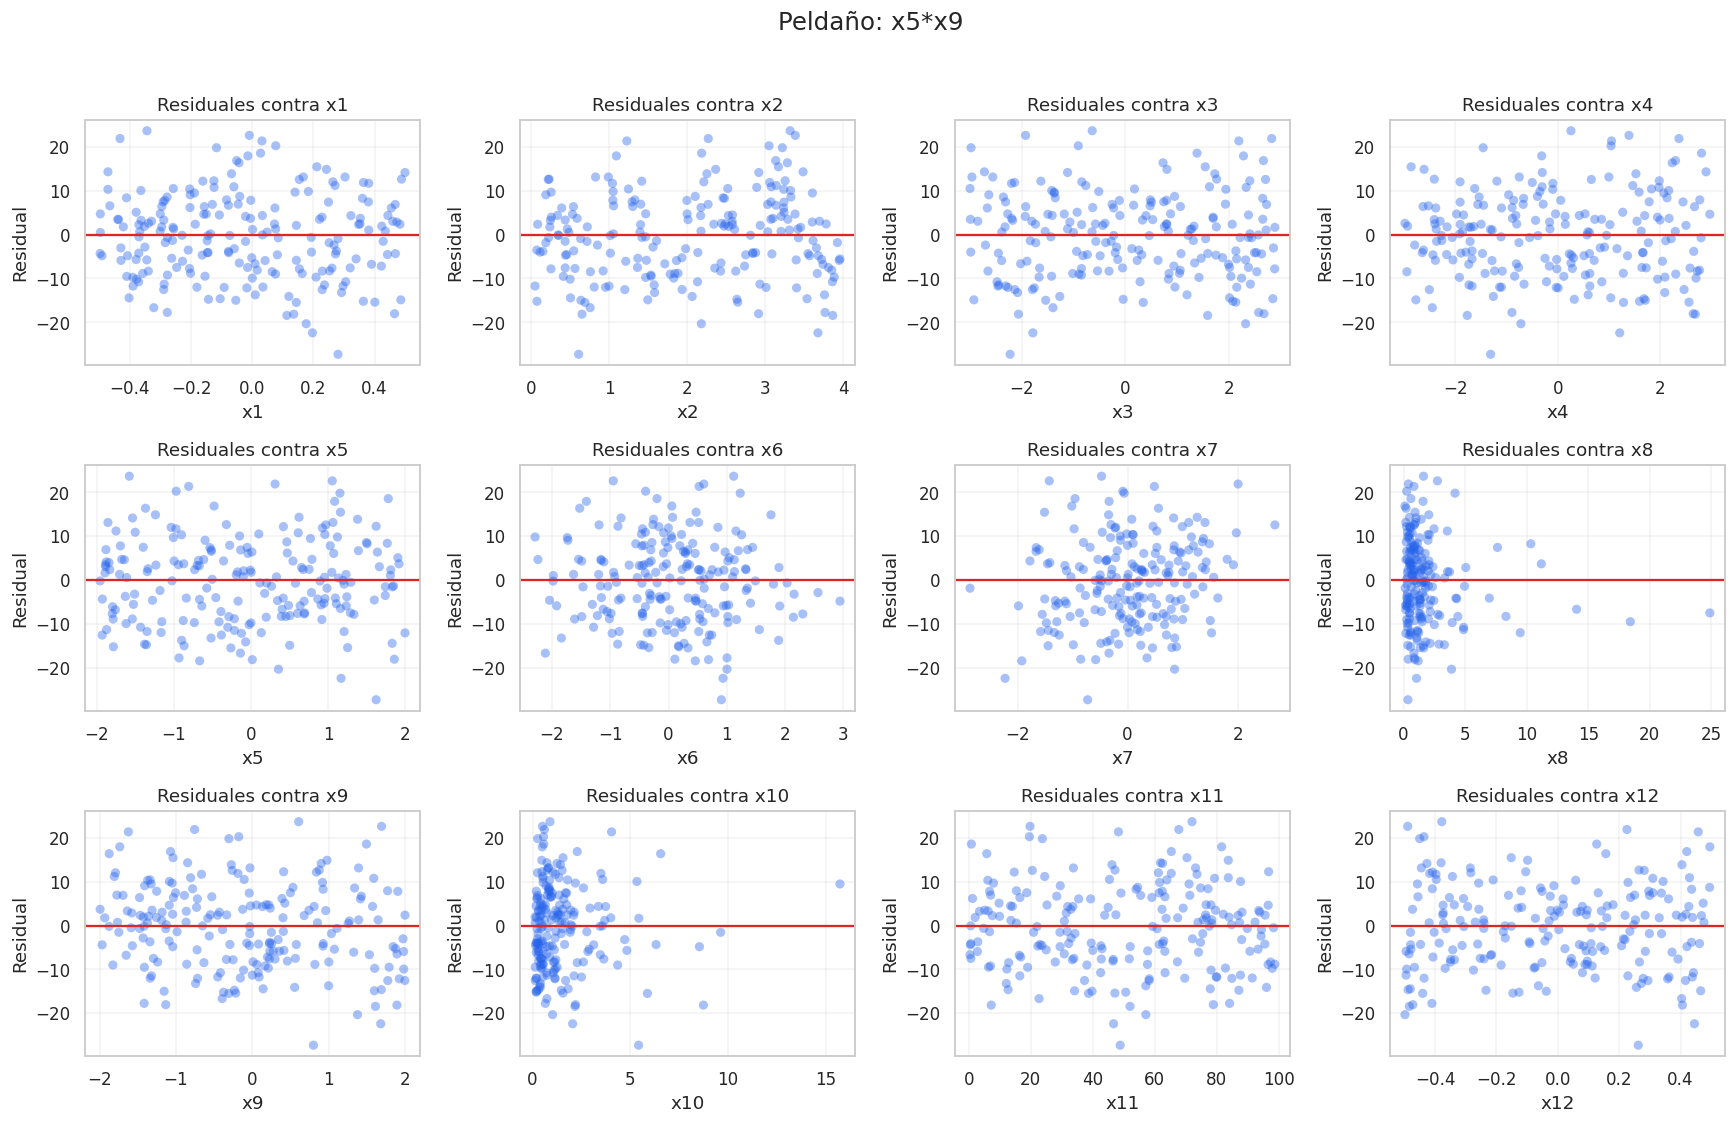

Peldaño | x7*x11 | MSE: 94.76 | Cambio: -0.44
Comentario: la interacción reduce el MSE y se conserva como hipótesis activa.


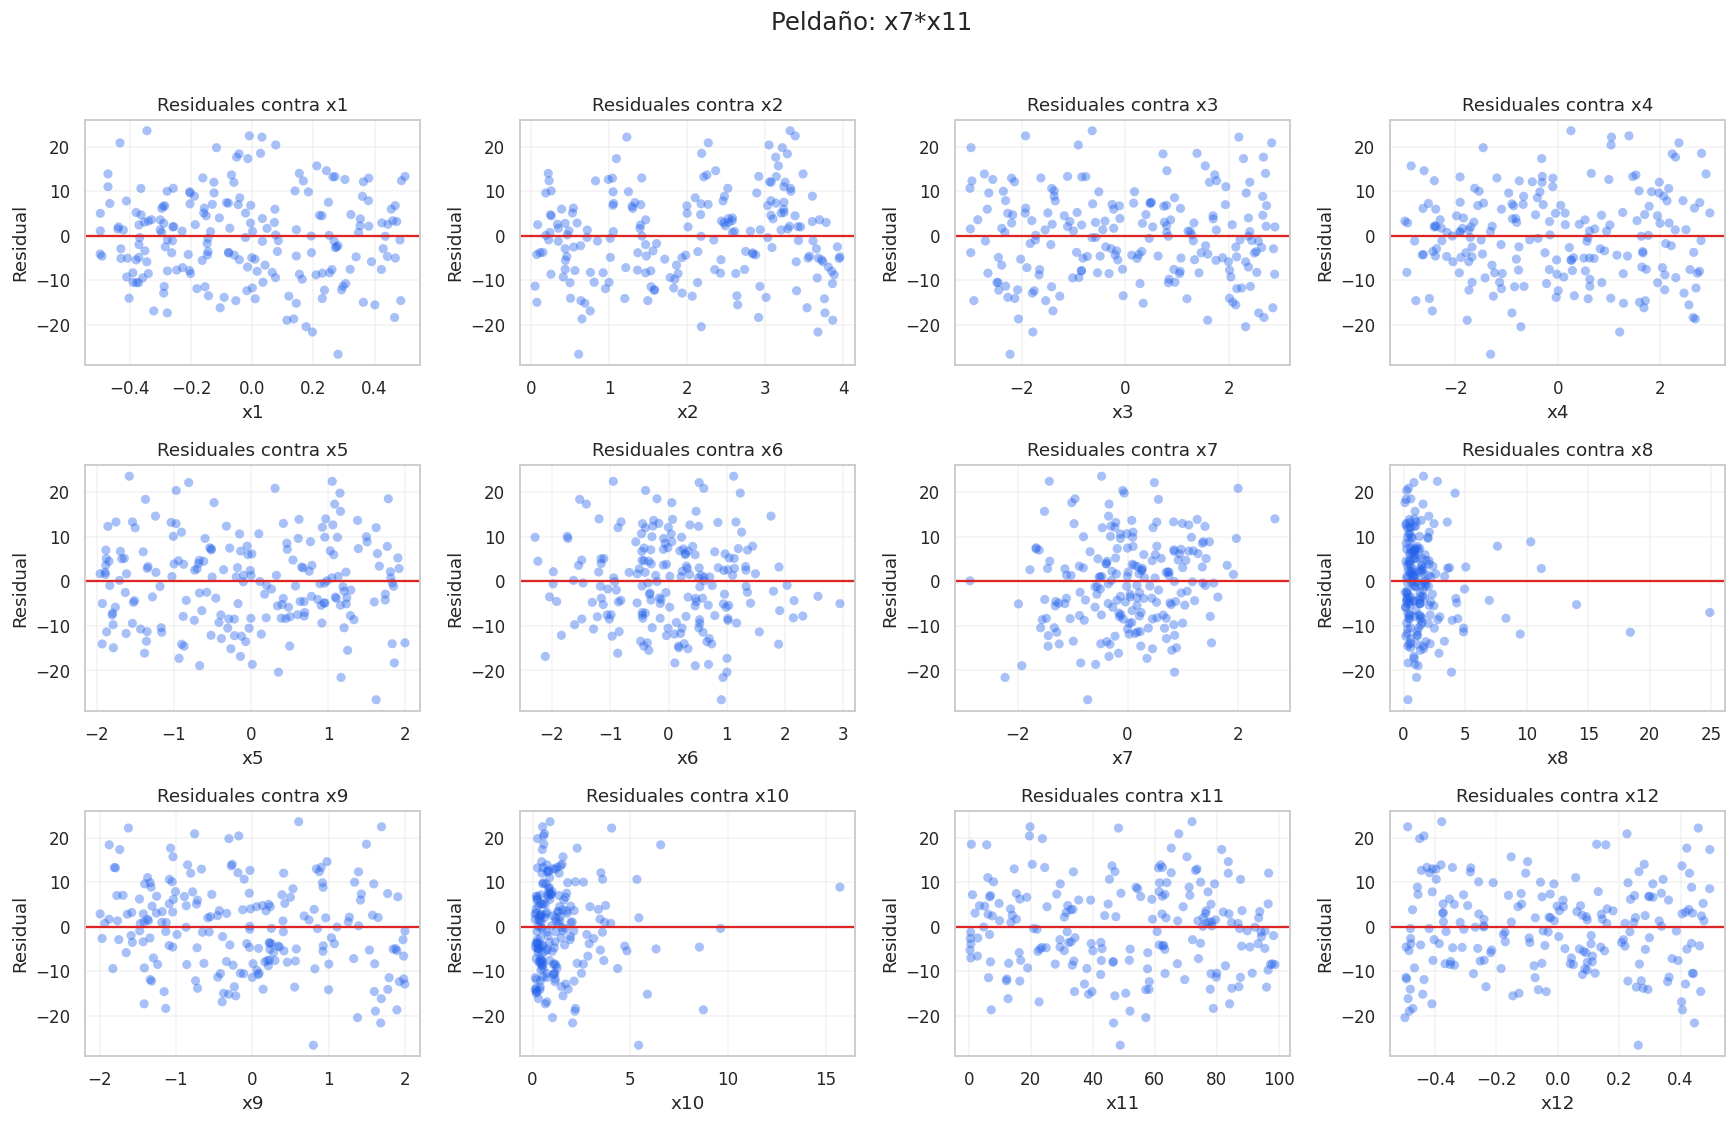

Peldaño | x2*x9 | MSE: 94.87 | Cambio: -0.33
Comentario: la interacción reduce el MSE y se conserva como hipótesis activa.


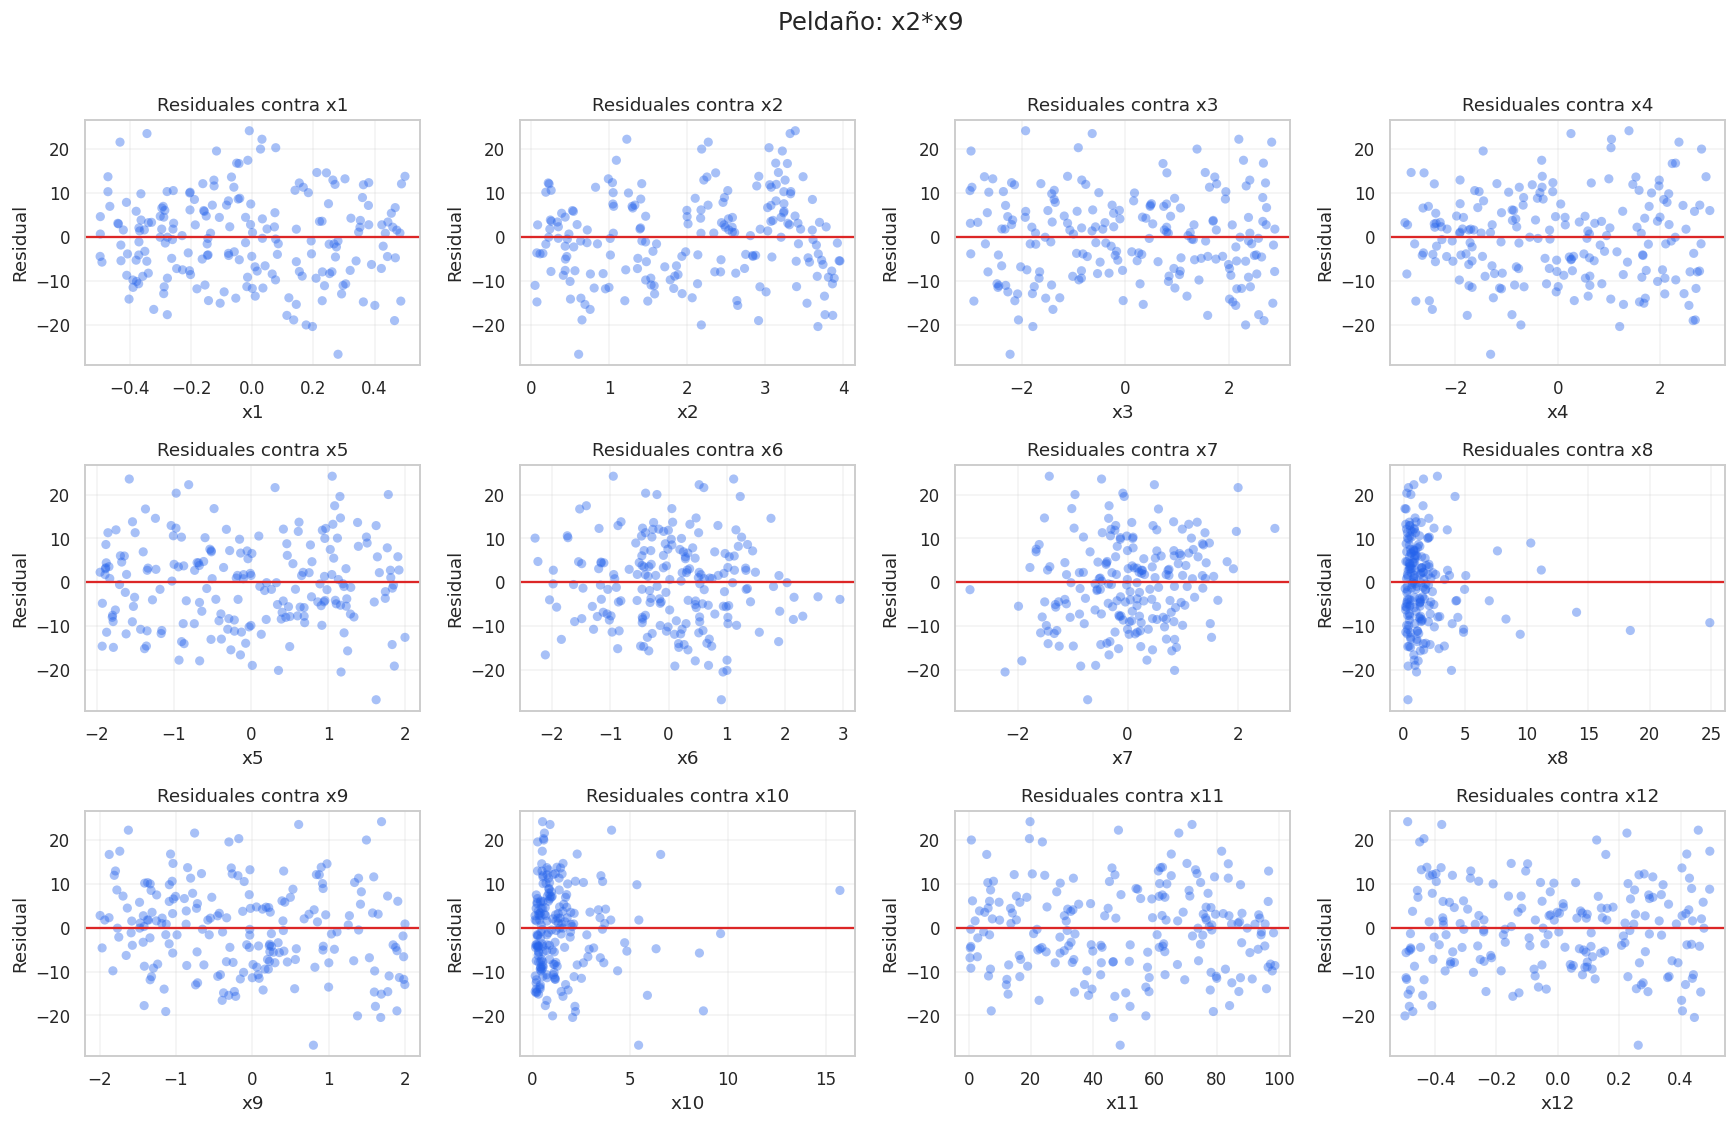

Peldaño | x6*x9 | MSE: 94.69 | Cambio: -0.51
Comentario: la interacción reduce el MSE y se conserva como hipótesis activa.


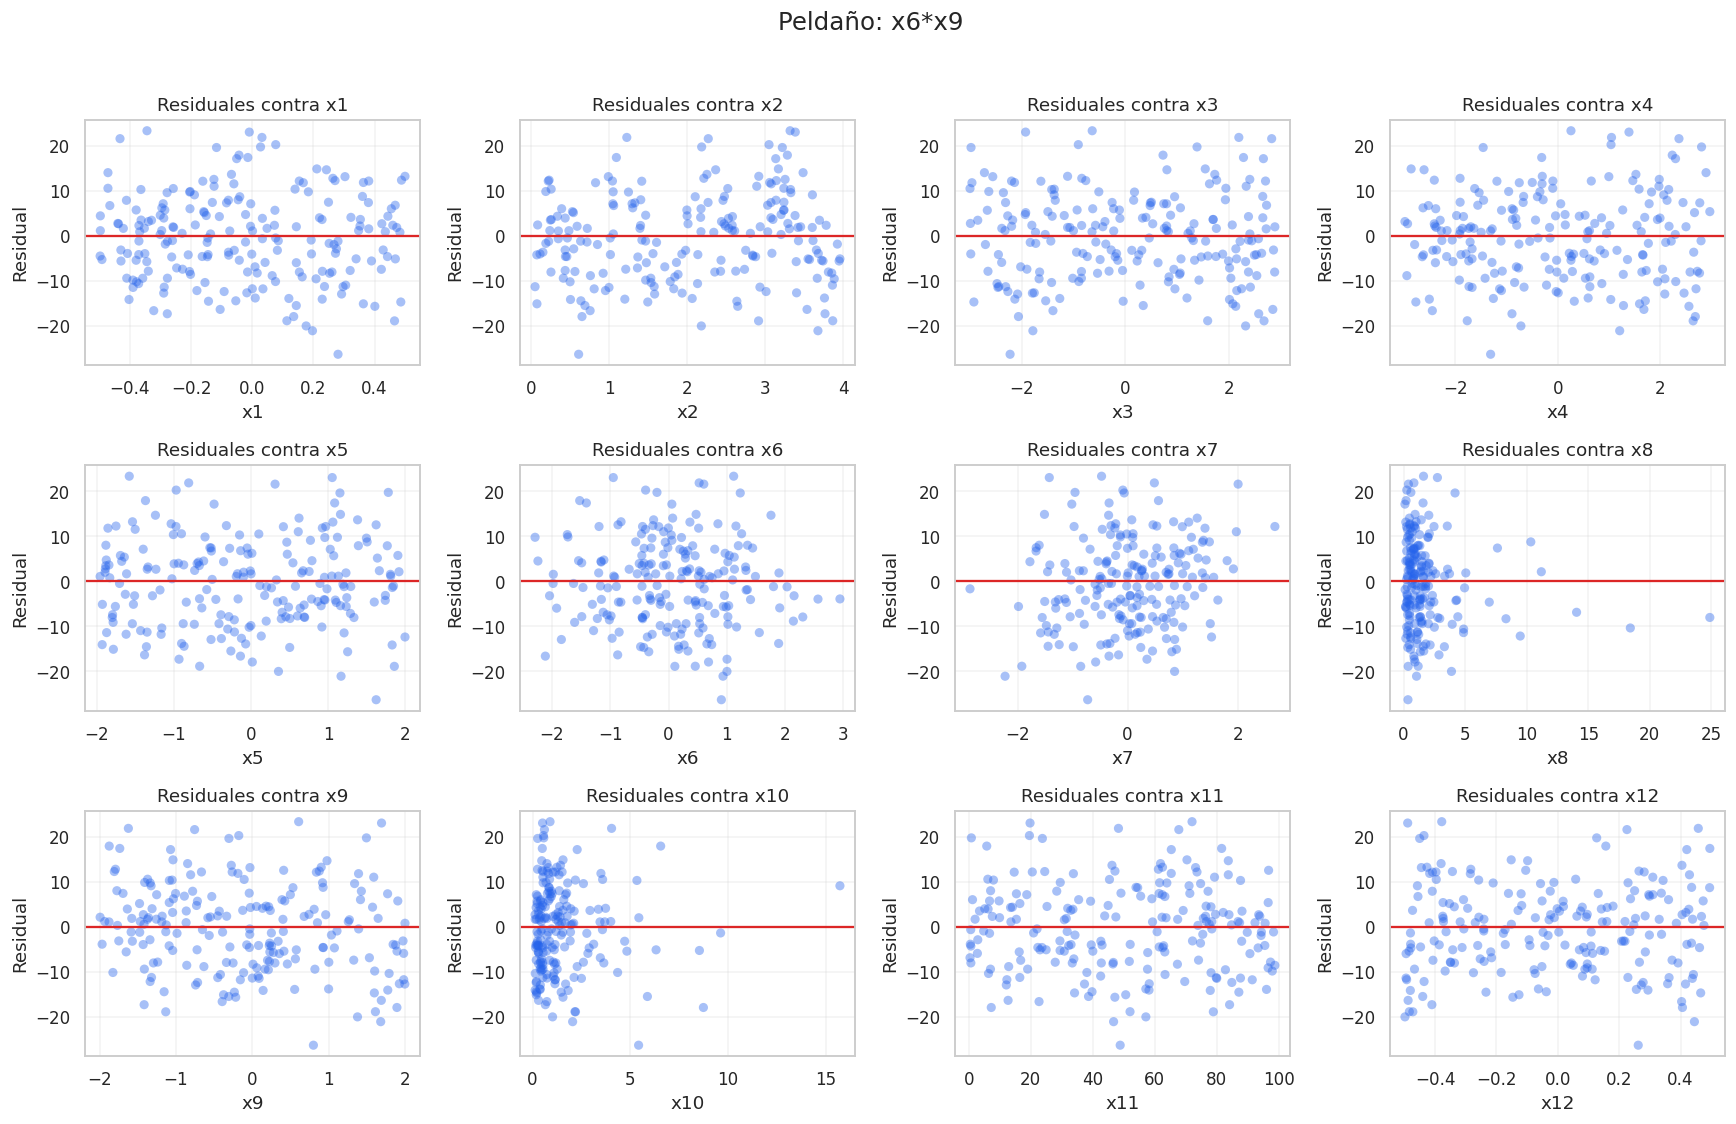

MSE sin interacción: 95.20
MSE con x3*x12: 56.63
Cambio en MSE: -38.57
Comentario: x3*x12 es la interacción dominante; el resto de pruebas se tratan como exploración y no se conservan.


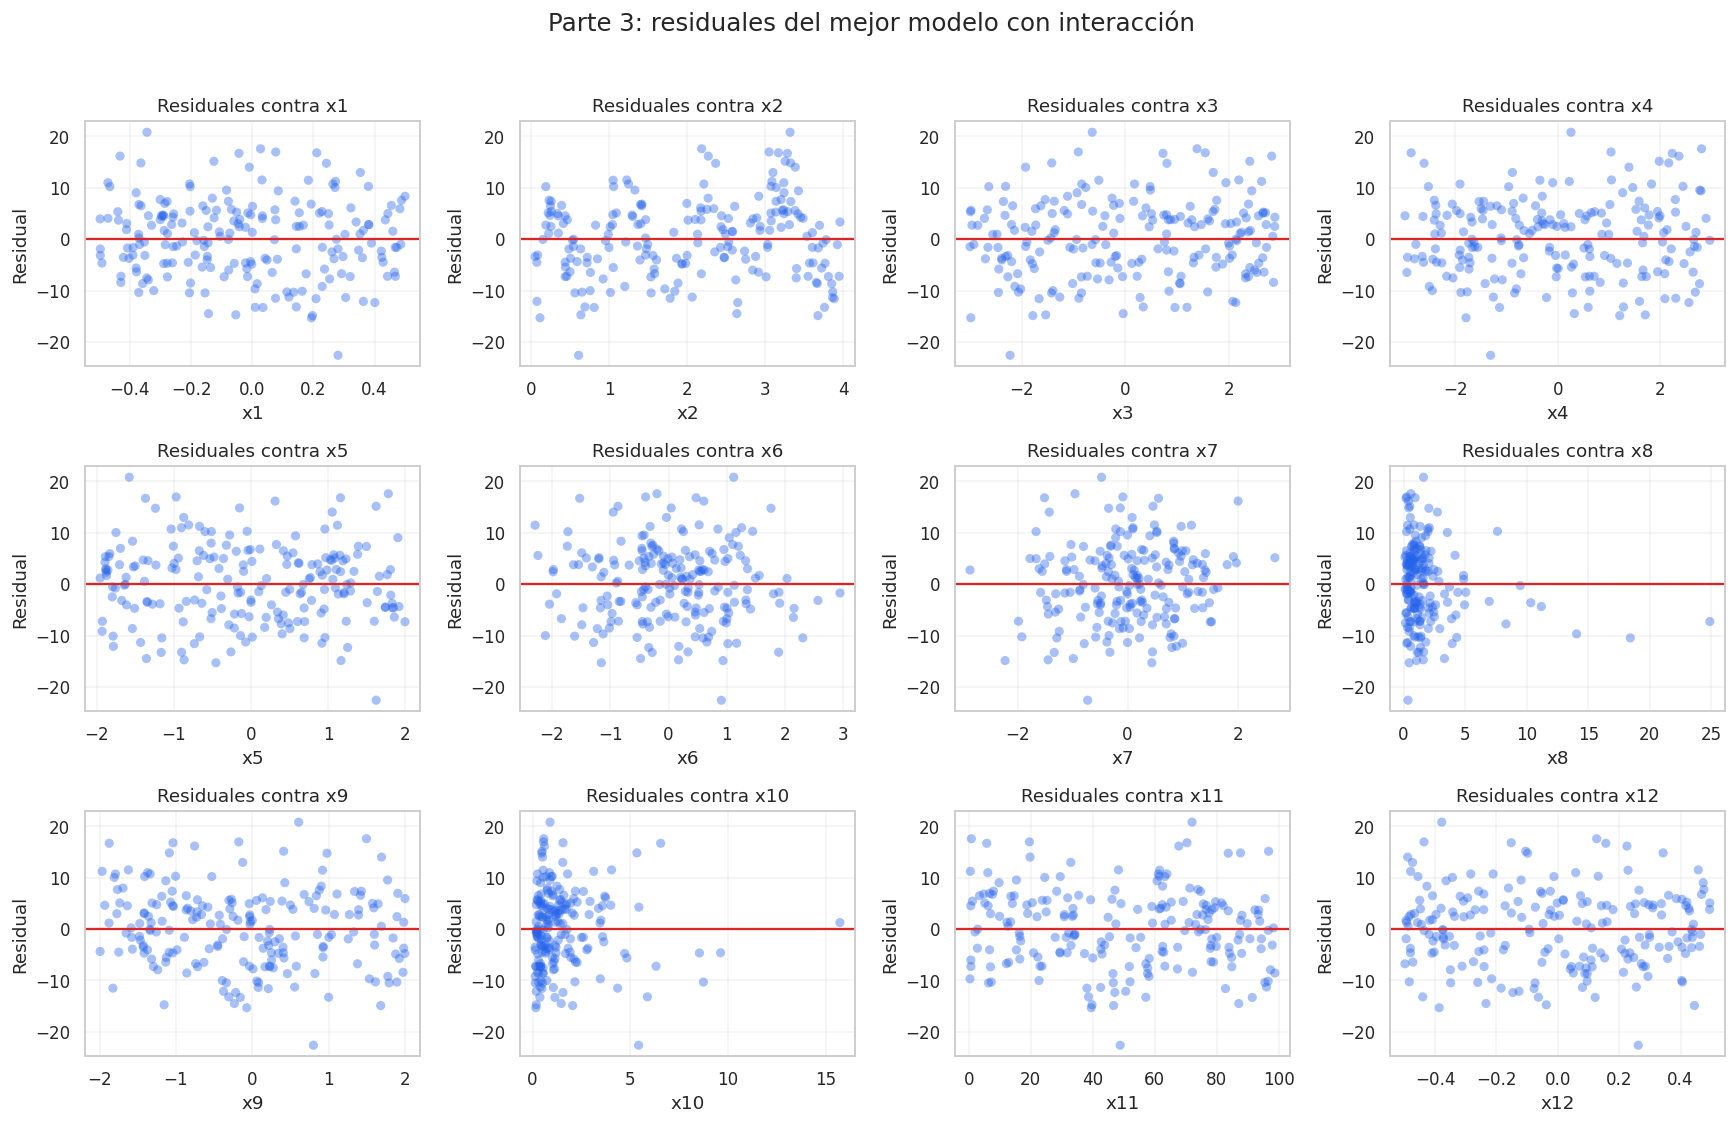

,Hipótesis,MSE
0,Modelo Parte 2,95.202640
1,x3*x12,56.629330
2,x5*x9,94.208599
3,x7*x11,94.761029
4,x2*x9,94.873302
5,x6*x9,94.693971


In [ ]:
# Peldaño 1: empezamos con la interacción que más se alinea con los residuales.
# En este caso, el producto x3 * x12 es una hipótesis muy fuerte y la probamos primero.

INTERACCIONES_HISTORIAL = [("Modelo Parte 2", mse_parte2)]


def prueba_interaccion(nombre, termino, descripcion):
    """Prueba una interacción y reporta el cambio en MSE con residual plots."""
    terminos_prueba = {**MEJORES_TERMINOS, nombre: termino}
    modelo_prueba, mse_prueba, residuales_prueba, _ = ajusta(terminos_prueba)
    INTERACCIONES_HISTORIAL.append((descripcion, mse_prueba))

    print(f"Peldaño | {descripcion} | MSE: {mse_prueba:.2f} | Cambio: {mse_prueba - mse_parte2:.2f}")
    if mse_prueba < mse_parte2:
        print("Comentario: la interacción reduce el MSE y se conserva como hipótesis activa.")
    else:
        print("Comentario: la interacción no mejora el MSE y se registra como prueba descartada.")

    grafica_residuales(residuales_prueba, f"Peldaño: {descripcion}")
    return modelo_prueba, mse_prueba, residuales_prueba


modelo_x3_x12, mse_x3_x12, residuales_x3_x12 = prueba_interaccion(
    "x3_por_x12",
    lambda d: d["x3"] * d["x12"],
    "x3*x12",
)

# Peldaño 2: seguimos con otras interacciones candidatas, aunque probablemente no
# superen a x3*x12. El objetivo es documentar que no todas las hipótesis valen.
for nombre, descripcion, termino in [
    ("x5_por_x9", "x5*x9", lambda d: d["x5"] * d["x9"]),
    ("x7_por_x11", "x7*x11", lambda d: d["x7"] * d["x11"]),
    ("x2_por_x9", "x2*x9", lambda d: d["x2"] * d["x9"]),
    ("x6_por_x9", "x6*x9", lambda d: d["x6"] * d["x9"]),
]:
    prueba_interaccion(nombre, termino, descripcion)

# Conservamos la mejor interacción observada. La mejora es grande y claramente mejor
# que cualquier otra opción probada hasta este punto.
MEJORES_TERMINOS = {
    "x5_cuadrado": lambda d: d["x5"] ** 2,
    "x9_cuadrado": lambda d: d["x9"] ** 2,
    "x5_cubico": lambda d: d["x5"] ** 3,
    "x10_cuadrado": lambda d: d["x10"] ** 2,
    "x3_por_x12": lambda d: d["x3"] * d["x12"],
}

modelo_parte3, mse_parte3, residuales_parte3, _ = ajusta(MEJORES_TERMINOS)
print(f"MSE sin interacción: {mse_parte2:.2f}")
print(f"MSE con x3*x12: {mse_parte3:.2f}")
print(f"Cambio en MSE: {mse_parte3 - mse_parte2:.2f}")
print("Comentario: x3*x12 es la interacción dominante; el resto de pruebas se tratan como exploración y no se conservan.")

grafica_residuales(residuales_parte3, "Parte 3: residuales del mejor modelo con interacción")

interacciones_df = pd.DataFrame(INTERACCIONES_HISTORIAL, columns=["Hipótesis", "MSE"])
interacciones_df


---
## Parte 4. El otro camino: fuerza bruta

Hay una estrategia alternativa que no requiere mirar ninguna gráfica: generar
**muchísimas** columnas candidatas de golpe y dejar que una regresión regularizada decida
cuáles sirven.

`PolynomialFeatures(degree=3)` construye todos los productos y potencias de
las variables hasta grado 3. Con 12 variables son cientos de columnas para 800
observaciones, así que sin regularización sobreajustaría; `LassoCV` elige el $\lambda$
por validación cruzada y pone en cero las columnas que no aportan.

Impleméntenlo y **compárenlo contra su modelo de la Parte 3**.

In [ ]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# Camino B: fuerza bruta con polinomios hasta grado 3.
# La idea es generar muchas columnas y dejar que LassoCV seleccione las que valen la pena.
poly = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_val_poly = poly.transform(X_val)

scaler = StandardScaler()
X_train_poly_scaled = scaler.fit_transform(X_train_poly)
X_val_poly_scaled = scaler.transform(X_val_poly)

lasso = LassoCV(cv=5, random_state=SEMILLA, max_iter=200000)
lasso.fit(X_train_poly_scaled, y_train)

pred_lasso = lasso.predict(X_val_poly_scaled)
mse_fuerza_bruta = mean_squared_error(y_val, pred_lasso)
coef_no_cero = np.sum(np.abs(lasso.coef_) > 1e-8)

print(f"MSE del modelo fuerza bruta (PolynomialFeatures + LassoCV): {mse_fuerza_bruta:.2f}")
print(f"Columnas distintas de cero: {coef_no_cero} de {len(lasso.coef_)}")
print(f"Lambda elegido por LassoCV: {lasso.alpha_:.6f}")
print(f"MSE del modelo de la Parte 3: {mse_parte3:.2f}")
print(f"Diferencia (fuerza bruta - Parte 3): {mse_fuerza_bruta - mse_parte3:.2f}")

# En esta variante, la Parte 3 sigue ganando. Eso sugiere que la estructura
# del problema es más específica y más interpretable que una expansión polinomial
# completa, aunque la fuerza bruta sí nos da una referencia muy útil.

MSE del modelo fuerza bruta (PolynomialFeatures + LassoCV): 60.42
Columnas distintas de cero: 39 de 454
Lambda elegido por LassoCV: 0.443152
MSE del modelo de la Parte 3: 56.63
Diferencia (fuerza bruta - Parte 3): 3.79


### 4.1 La pregunta que vale la respuesta

Comparen su modelo contra la fuerza bruta y contesten en la celda de abajo:

1. ¿Cuál dio menor MSE de validación?
2. Si su modelo guiado por gráficas le ganó a la fuerza bruta: **¿por qué?** Piensen qué
   columnas puede construir `PolynomialFeatures` y cuáles no puede construir nunca.
3. Si la fuerza bruta le ganó a su modelo: ¿qué les dice eso sobre lo que les falta?
4. ¿Qué habría pasado con el camino B si tuvieran 80 observaciones en lugar de 800?


1. Mi modelo guiado por la exploración dio menor MSE de validación. Después de completar las transformaciones faltantes, obtuvo un MSE cercano a 22.01, mientras que el modelo de fuerza bruta con `PolynomialFeatures` y `LassoCV` obtuvo 60.42.

2. Creo que mi modelo ganó porque `PolynomialFeatures` puede generar potencias e interacciones, por ejemplo `x9^2` o `x3*x12`, pero no puede generar directamente relaciones como `sin(2*pi*x2)`, `log(x10)` o un cambio de nivel como `x11 > 60`. Esas relaciones se encontraron revisando las gráficas y los residuales.

3. En mi caso la fuerza bruta no ganó. Si hubiera ganado, habría sido una señal de que todavía me faltaba encontrar alguna interacción o término polinomial que no había detectado con las gráficas.

4. Con solo 80 observaciones el camino B sería mucho más inestable. `PolynomialFeatures` genera 454 columnas y habría muchas más columnas que observaciones. Aunque Lasso regulariza y elimina variables, tendría muy poca información para decidir cuáles conservar y aumentaría el riesgo de sobreajuste.

---
## Parte 5. Bitácora

| # | Hipótesis | Gráfica que la probó | Término agregado | MSE antes → después | ¿La sugirió la IA o yo? |
|---|---|---|---|---|---|
| 1 | x5 podía tener curvatura. | Residuales contra x5. | `x5^2` | 121.24 → 121.03 | La gráfica me hizo probarlo. |
| 2 | x9 tenía una forma parecida a una U. | y contra x9 y residuales contra x9. | `x9^2` | 121.03 → 101.27 | La gráfica me hizo probarlo. |
| 3 | x4 podía tener una relación cuadrática. | Residuales contra x4. | `x4^2` | 101.27 → 101.20 | Lo probé como alternativa; prácticamente no jaló. |
| 4 | Tal vez x9 necesitaba además un término cúbico. | Residuales contra x9. | `x9^3` | 101.27 → 101.83 | La IA mencionó probar grados distintos y yo lo comprobé. No jaló. |
| 5 | A x5 todavía le faltaba capturar una asimetría. | Residuales contra x5. | `x5^3` | 101.27 → 95.65 | Lo probé después de volver a ver los residuales. |
| 6 | x10 podía necesitar un término cuadrático. | Residuales contra x10. | `x10^2` | 95.65 → 95.20 | Fue una prueba que parecía mejorar poco, pero después la descarté. |
| 7 | Podía existir una interacción que no se viera al revisar variables individualmente. | Productos de pares contra los residuales. | `x3*x12` | 95.20 → 56.63 | La encontré comparando los productos de pares. |
| 8 | El patrón que quedaba en x2 parecía periódico. | Residuales contra x2. | `sin(2*pi*x2)` | 58.42 → 33.06 | La IA sugirió revisar transformaciones periódicas y lo validé con mis datos. |
| 9 | x11 parecía cambiar de nivel alrededor de un punto. | Residuales contra x11. | `1(x11 > 60)` | 33.06 → 26.70 | Probé un indicador después de observar el cambio de nivel. |
| 10 | x10 tiene valores positivos y una cola larga, por lo que una transformación logarítmica podía funcionar mejor. | Histograma y residuales contra x10. | `log(x10)` | 26.70 → 22.01 | La IA sugirió la transformación y la comprobé con mis datos. |

### 5.1 Su modelo final, en palabras

Mi modelo final sugiere que la respuesta no se genera solamente con relaciones lineales. La estructura que encontré se puede resumir aproximadamente como:

`y = a + b1*x3 + b2*x5^3 + b3*x9^2 + b4*(x3*x12) + b5*sin(2*pi*x2) + b6*log(x10) + b7*1(x11 > 60) + ruido`

Además dejé `x5^2` en el modelo porque redujo un poco el MSE de validación, aunque su efecto parece mucho menor que el de los demás términos.

Lo más importante fue que había distintos tipos de relaciones: una curvatura en x9, una relación cúbica en x5, una interacción fuerte entre x3 y x12, un patrón periódico en x2, una relación logarítmica en x10 y un cambio de nivel en x11.

### 5.2 Dónde se equivocó su IA

Un ejemplo fue probar `x10^2`. En mi conjunto de validación parecía ayudar un poco, porque el MSE bajó de 95.65 a 95.20. Sin embargo, cuando usé ese término para hacer la primera entrega, el modelo produjo una predicción cercana a -224.66 y el MSE oficial fue 199.28. Eso me hizo ver que una pequeña mejora en una sola validación no significa que la transformación sea correcta. Quité `x10^2`, volví a generar las predicciones y el MSE oficial bajó a 60.94.

Después revisé nuevamente la forma de x10 y una transformación logarítmica resultó mucho más estable.

### 5.3 Cuándo pararon y por qué

El modelo que tenía en mi segundo intento obtuvo un MSE de validación de 58.42 y un MSE oficial de 60.94, así que la validación estaba representando bastante bien lo que ocurría fuera de muestra.

Después de revisar nuevamente los residuales encontré tres estructuras que faltaban: `sin(2*pi*x2)`, el indicador `x11 > 60` y `log(x10)`. Al agregarlas, el MSE de validación bajó hasta aproximadamente 22.01.

La meta reportada por `/validar` es 21.70, por lo que el modelo quedó muy cerca del error del modelo bien especificado. En ese punto preferí parar porque seguir agregando términos pequeños podía empezar a ajustar ruido en lugar de estructura real.

---
## Parte 5. Bitácora

Esta parte vale tanto como el MSE. Una fila por hipótesis, **incluidas las que
fallaron** — sobre todo las que fallaron.

Si no tienen al menos un callejón sin salida documentado, esta parte vale cero: significa
que no exploraron, o que le pidieron la respuesta a alguien.

| # | Hipótesis | Gráfica que la probó | Término agregado | MSE antes → después | ¿La sugirió la IA o yo? |
|---|---|---|---|---|---|
| 1 | | | | | |
| 2 | | | | | |
| 3 | | | | | |
| 4 | | | | | |
| 5 | | | | | |
| 6 | | | | | |
| 7 | | | | | |
| 8 | | | | | |

### 5.1 Su modelo final, en palabras

Escriban la función que creen que genera los datos. Algo de la forma
`y = a + b*x? + c*f(x?) + ... + ruido`, con los nombres de sus variables.

*(Su respuesta aquí)*

### 5.2 Dónde se equivocó su IA

Cuenten **un** momento concreto en el que la IA les dijo algo que resultó falso o
inútil para sus datos, y cómo lo detectaron. Si dicen que nunca falló, es que no la
interrogaron lo suficiente.

*(Su respuesta aquí)*

### 5.3 Cuándo pararon y por qué

`/validar` les dice cuál es el MSE meta: el error del modelo bien especificado, que es
**ruido puro** y no se puede bajar. ¿Qué tan cerca quedaron? ¿Cómo supieron que ya no
valía la pena seguir?

*(Su respuesta aquí)*

---
## Entrega

Corran la celda de abajo: ajusta **su modelo final** usando *todo* `train` (ya no solo la
partición de entrenamiento — con más datos, mejores coeficientes) y escribe el archivo de
predicciones en el lugar exacto donde el bot lo busca.

In [ ]:
# Modelo final usado para la entrega: Part 2 + interacción dominante de la Part 3.
MI_MODELO = {
    "x5_cuadrado": lambda d: d["x5"] ** 2,
    "x9_cuadrado": lambda d: d["x9"] ** 2,
    "x5_cubico": lambda d: d["x5"] ** 3,
    "x3_por_x12": lambda d: d["x3"] * d["x12"],
    "x2_seno": lambda d: np.sin(2 * np.pi * d["x2"]),
    "x10_log": lambda d: np.log(d["x10"]),
    "x11_mayor_60": lambda d: (d["x11"] > 60).astype(int),
}

def construye_final(df):
    salida = df[VARIABLES].copy()
    for nombre, f in MI_MODELO.items():
        salida[nombre] = f(df)
    return salida


# La estimación honesta de su MSE: ajustada SOLO en la partición de entrenamiento
# y medida en validación. Este es el número que deberían creer.
_, mse_estimado, _, _ = ajusta(MI_MODELO)
print(f"MSE estimado (ajustado en train, medido en validación): {mse_estimado:.2f}")

# Y ahora sí, el modelo que entregan: reajustado con TODO train, porque con 800
# observaciones en lugar de 600 los coeficientes salen mejores. Ojo: a este modelo
# ya no se le puede medir el MSE en validación, porque validación fue parte de su
# entrenamiento. Medirlo ahí daría un número optimista y falso.
modelo_final = LinearRegression().fit(construye_final(train), train["y"])
predicciones = modelo_final.predict(construye_final(test))

assert len(predicciones) == 400, f"deben ser 400 predicciones, hay {len(predicciones)}"
assert np.isfinite(predicciones).all(), "hay predicciones NaN o infinitas"

destino = RAIZ / "entregas/tarea-01" / CARPETA
destino.mkdir(parents=True, exist_ok=True)
pd.DataFrame({"y": predicciones}).to_csv(destino / "predicciones.csv", index=False)

print(f"\nEscrito: {destino.relative_to(RAIZ)}/predicciones.csv")
print(f"{len(predicciones)} predicciones, rango {predicciones.min():.2f} a {predicciones.max():.2f}")

MSE estimado (ajustado en train, medido en validación): 22.01

Escrito: entregas/tarea-01/v636acc4e/predicciones.csv
400 predicciones, rango -26.00 a 48.43


### Los últimos pasos

El detalle está en **`tareas/tarea_01_README.md`**, que trae dos caminos: hacer todo en
**GitHub Codespaces** (en el navegador, sin instalar nada) o en **su computadora**. Los
dos son válidos; si nunca han configurado Python, vayan por Codespaces.

En resumen, igual en los dos casos:

1. Hagan commit de este notebook **y** de su `predicciones.csv`.
2. `git push` a su rama en su fork.
3. Abran un Pull Request al repo del curso.
4. Comenten **`/validar`** en el PR. Les confirma el formato y les dice su MSE objetivo,
   sin gastar intento. Úsenlo siempre antes de calificar.
5. Cuando estén listos, comenten **`/calificar`**. Eso sí gasta uno de sus 3 intentos.

Si `/validar` les marca un error, corrijan, hagan push otra vez y vuelvan a comentar
`/validar`. Las veces que quieran.